In [317]:
! pip install fredapi
import torch
import math
from torch import nn
from google.colab import drive
import sys
sys.path.append('/content/drive/MyDrive/ML_Project_Data')
drive.mount('/content/drive',force_remount=True)
import sys
import pandas as pd
import requests
from fredapi import Fred
from MacroData_MLProject import FredMacroData
from Stock_MLProject import StockSequenceBuilder
from Text_MLProject import NewsEmbeddingPipeline
import d2l
from Utilities import download_data, normalize
import warnings
warnings.filterwarnings("ignore")

Mounted at /content/drive


# Introduction

The goal of this project is to investigate whether news and macroeconomic context
can improve next-day stock return prediction for a specific stock.

The main idea is to use the attention mechanism of a Transformer as a context
retrieval system: given the current market environment, the model should identify
similar past environments and use them for the prediction.

To represent the environment, the dataset is composed of three modalities:
- Financial data: technical indicators of major stocks
- Macroeconomic data: Fed-relevant indicators, treasury dynamics, employment
  and inflation data with countdowns to publication dates
- News embeddings: daily summaries of stock-specific news

For each modality, some specific decisions were made.

**Financial data**: the features include technical
indicators, and other variables that capture the dynamics of the chosen stock.
A ticker column is also present, but never used in this notebook. It was created to keep the
framework general: having data from multiple tickers could be useful given the
limited number of observations, but this will not be investigated here.
Also, I removed the return of correlated stock, because seemed to ruin the model

**News**: instead of computing a daily embedding by averaging multiple news items,
the news were first concatenated and then embedded as a single text. The embeddings
were also normalized, as without normalization their scale was smaller than the other
features and the model tended to ignore them, despite that the model was able to retrieve
past similar events.

**Macroeconomic data**: features were selected and transformed to be comparable
over time. The countdown to the next release date was included as a meaningful
feature, but normalized differently: rather than applying a standard scaler, it was
transformed as 1/days_to_next_release to preserve the ordering and maintain a
coherent scale.

All features are designed to be repeatable over time, so that the dot-product similarity between past and
present environments is meaningful.

# Download the data

First we need to create the dataset.

This notebook is going to be mainly focused on the creation of the transformer architecture needed and its training.
That's why I'm going to simply import the necessary parts in order to build the dataset and avoid to fill the notebook with long parts of code, despite being a fundemental part.

In [318]:
# The download_data and the normalize functions from utilities, take care of the split and normalization of the dataset, in order to have a ready train and test dataset.
merge_df,TEXT_FEATURES_ALL,FIN_FEATURES_ALL,MACRO_FEATURES_ALL,macro_features_with_days_to_next,all_cols_with_lags=download_data("TSLA","Elon Musk","Tesla","PCA",30,0)
#Overall the classes were made in order to be generic, so they work for different stocks and Target
merge_df["Ticker"] = 0
merge_df.dropna(inplace=True)

train_df, test_df, target_scaler = normalize(
    merge_df,
    "Return",
    -1,
    MACRO_FEATURES_ALL,
    FIN_FEATURES_ALL,
    TEXT_FEATURES_ALL,
    macro_features_with_days_to_next
)


Feature macro giornaliere: ['unemployment', 'unemployment_days_to_next', 'cpi_pct_change', 'cpi_days_to_next', 'fedfunds_pct_change', 'm2_money_pct_change', 'm2_money_days_to_next', 'vix_pct_change', 'cpi_year', 'cpi_year_days_to_next', 'treasury_10y']


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/36 [00:00<?, ?it/s]

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
6 Failed downloads:
ERROR:yfinance:['MMC', 'IPG', 'K', 'BRK.B', 'FI']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-01-01 -> 2026-01-01)')
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  13 of 13 completed


Shape input Transformer: (3711, 69)


## Row with negative news

First we would like to retrive the dates with negative news. Later you will understand why.

In [319]:
pipeline = NewsEmbeddingPipeline(choice="pca")

file_path="/content/drive/MyDrive/ML_Project_Data/SummaryAndNews.csv"

df_text_original=pipeline.download_text(
        file_path,
        "Tesla",
        "Elon Musk",
        "TSLA"
    )

df_emb=pipeline.compute_embeddings(df_text_original)
df_text= pipeline.embedding_or_pca(30,df_emb)

series_delta,series_no_delta, df_similarity_filtered=pipeline.checkTheSimilarityEmb(df_text,"Tesla's stock dropped")
df_text.drop(columns=["economics_finance"],inplace=True)
df_text.drop_duplicates(inplace=True)
df_text.sort_values("Date",inplace=True)
df_text.reset_index(inplace=True)

print(series_delta)
print("-------------")
print(series_no_delta)
print("-------------")
print(df_similarity_filtered)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/36 [00:00<?, ?it/s]

[*********************100%***********************]  1 of 1 completed

Date
2013-12-19   -0.049061
2014-08-11    0.045097
2014-12-17    0.040493
2017-05-15   -0.027493
2017-11-13    0.040958
2018-01-09   -0.008085
2019-06-06    0.047612
2019-07-25   -0.136137
Name: Return, dtype: float64
-------------
Date
2013-12-20    0.017908
2014-08-12    0.002468
2014-09-29   -0.005434
2014-12-18    0.060441
2017-05-16    0.003577
2017-11-14   -0.021243
2018-01-10    0.003326
2019-03-18   -0.021566
2019-06-07   -0.007041
2019-07-26   -0.003409
Name: Return, dtype: float64
-------------
760    - Tesla's stock dropped nearly 14% on Thursday...
70     - Tesla shares down over 4% following reports ...
360    - Tesla shares fell 3% after Morgan Stanley do...
435    - Shares of Tesla closed down 2.1 percent foll...
113    - Tesla's stock experienced a minor decrease o...
142    - Tesla shares have lost more than $1 billion ...
687    - Tesla shares have experienced a significant ...
126    - Tesla shares have lost 11% since Sept. 4, bu...
461    - Tesla shares had a strong

In [320]:
DatesWithNegativeNews=series_no_delta.index

In [321]:
DatesWithNegativeNews

DatetimeIndex(['2013-12-20', '2014-08-12', '2014-09-29', '2014-12-18',
               '2017-05-16', '2017-11-14', '2018-01-10', '2019-03-18',
               '2019-06-07', '2019-07-26'],
              dtype='datetime64[ns]', name='Date', freq=None)

# Build the transformer architecture step by step

From d2l.ai

The main purpose of this section is to understand if the dot product attention could be used for context retrival. So I expect the function to give a higher score to past similar event

Lets start with:
$$
\alpha(\mathbf{q}, \mathbf{k}) =
\exp\left(-\frac{1}{2}\|\mathbf{q}-\mathbf{k}\|^2\right)
\quad \text{Gaussian}
$$

The attention score can be written as:

$$
a(\mathbf{q}, \mathbf{k}_i) = -\frac{1}{2}\|\mathbf{q}-\mathbf{k}_i\|^2
= \mathbf{q}^\top \mathbf{k}_i
- \frac{1}{2}\|\mathbf{k}_i\|^2
- \frac{1}{2}\|\mathbf{q}\|^2
\tag{11.3.1}
$$
the final term depends on q, so it is identical for all pairs (q,k). Normalizing the attention weights to 1, ensures that this term disappears entirely. Layer normalization lead to constant norms, so whenever the keys were generated by a layer norm we can drop the alone k.

Assume that all the elements of the query and the key are independent and identically drawn random variables with zero mean and unit variance. The dot product between both vectors has zero mean and a variance of d. To ensure that the variance of the dot product still remains 1 regardless of vector length, we use the scaled dot product attention scoring function.

To control the magnitude of the arguments in the exponential function, we use the **scaled dot-product attention**:

$$
a(\mathbf{q}, \mathbf{k}_i) = \frac{\mathbf{q}^\top \mathbf{k}_i}{\sqrt{d}}
\tag{11.3.2}
$$

The attention weights are then normalized with the **softmax** function:

$$
\alpha(\mathbf{q}, \mathbf{k}_i)
=
\text{softmax}(a(\mathbf{q}, \mathbf{k}_i))
=
\frac{\exp(\mathbf{q}^\top \mathbf{k}_i / \sqrt{d})}
{\sum_{j=1}^{n} \exp(\mathbf{q}^\top \mathbf{k}_j / \sqrt{d})}
\tag{11.3.3}
$$

Layer Normalization
$$
y = \frac{x - \mathbb{E}[x]}{\sqrt{\mathrm{Var}[x] + \epsilon}} * \gamma + \beta
$$

From the prevoius step we obtained our dataset, composed by train_df and test_df. So it is already split it

In [322]:
#The dataset is composed by the following features
features=MACRO_FEATURES_ALL + FIN_FEATURES_ALL + TEXT_FEATURES_ALL + macro_features_with_days_to_next

In [323]:
#Check the highest downturn, we may want to look to similar past return's drops
merge_df[["Return","Date"]].sort_values(by="Return").head(10)

,Return,Date
2505,-0.236518,2020-09-08
341,-0.214772,2012-01-13
2385,-0.205522,2020-03-16
2358,-0.188450,2020-02-05
2387,-0.174763,2020-03-18
3634,-0.167546,2025-03-10
76,-0.163556,2010-12-27
797,-0.156737,2013-11-06
717,-0.154426,2013-07-16
3695,-0.153849,2025-06-05


First, we may want to look to similar past return's drops using the attention function, the one we will use also later in the Transformer, in order to understand whether actually find similar pattern.

## Attention function step by step on train data

In [324]:
import numpy as np
columns=features #Using all features, we may want to retrive one of the highest drops
d=len(columns)

train_df_tensor=torch.tensor(train_df[columns].values)
train_df_tensor = train_df_tensor.float()

layer_norm=nn.LayerNorm(d) # Normalization in order to have constant norm
dataset_norm=layer_norm(train_df_tensor)
q=dataset_norm[2505] #Lets look for the highest drop

attention=(q@dataset_norm.T)/np.sqrt(d)
attention_softmax=nn.functional.softmax(attention,dim=-1) # Softmax so we can justify the absence of q

attention_softmax=attention_softmax.detach().numpy()

Scores=pd.DataFrame(attention_softmax)[0].sort_values(ascending=False).head(10)*100
topIDs=Scores.index

print("The dataset")
print(train_df.iloc[topIDs][["Return","Date"]])
print("\n")
print("Using all the features")
print("Scores")
print(Scores)
print("\n")
print("The non normalized dataset: ")
print(merge_df.iloc[topIDs][["Return","Date"]])


The dataset
        Return       Date
2505 -6.706064 2020-09-08
341  -6.093554 2012-01-13
76   -4.650996 2010-12-27
805  -3.087046 2013-11-18
920  -3.422841 2014-05-08
717  -4.393838 2013-07-16
2503 -2.708005 2020-09-03
1361 -2.696054 2016-02-08
801  -1.420425 2013-11-12
317  -2.903139 2011-12-08


Using all the features
Scores
2505    22.286131
341      2.356813
76       1.962878
805      1.921690
920      1.676952
717      1.463420
2503     1.207602
1361     0.992199
801      0.959175
317      0.900815
Name: 0, dtype: float32


The non normalized dataset: 
        Return       Date
2505 -0.236518 2020-09-08
341  -0.214772 2012-01-13
76   -0.163556 2010-12-27
805  -0.108030 2013-11-18
920  -0.119952 2014-05-08
717  -0.154426 2013-07-16
2503 -0.094573 2020-09-03
1361 -0.094148 2016-02-08
801  -0.048859 2013-11-12
317  -0.101501 2011-12-08


Another aspect to note is how the scores are distributed, the first takes all the score, which later will be a problem.
At the next cell I try to do the same without considering the key

In [325]:
idx = 2505
dataset_norm_excl = torch.cat([dataset_norm[:idx], dataset_norm[idx+1:]], dim=0)
attention = (q @ dataset_norm_excl.T) / np.sqrt(d)
attention_softmax = nn.functional.softmax(attention, dim=-1)

attention_softmax=attention_softmax.detach().numpy()

Scores=pd.DataFrame(attention_softmax)[0].sort_values(ascending=False).head(10)*100
topIDs=Scores.index
print("The dataset")
print(train_df.iloc[topIDs][["Return","Date"]])
print("\n")
print("Using all the features,\nbut without considering the key")
print("Scores")
print(Scores)
print("\n")
print("The non normalized dataset: ")
print(merge_df.iloc[topIDs][["Return","Date"]])


The dataset
        Return       Date
341  -6.093554 2012-01-13
76   -4.650996 2010-12-27
805  -3.087046 2013-11-18
920  -3.422841 2014-05-08
717  -4.393838 2013-07-16
2503 -2.708005 2020-09-03
1361 -2.696054 2016-02-08
801  -1.420425 2013-11-12
317  -2.903139 2011-12-08
477  -2.185235 2012-07-30


Using all the features,
but without considering the key
Scores
341     3.032681
76      2.525776
805     2.472776
920     2.157853
717     1.883087
2503    1.553908
1361    1.276734
801     1.234239
317     1.159143
477     1.082439
Name: 0, dtype: float32


The non normalized dataset: 
        Return       Date
341  -0.214772 2012-01-13
76   -0.163556 2010-12-27
805  -0.108030 2013-11-18
920  -0.119952 2014-05-08
717  -0.154426 2013-07-16
2503 -0.094573 2020-09-03
1361 -0.094148 2016-02-08
801  -0.048859 2013-11-12
317  -0.101501 2011-12-08
477  -0.076013 2012-07-30


### Are text features necessary?

In [326]:
import numpy as np
columns= FIN_FEATURES_ALL+macro_features_with_days_to_next + MACRO_FEATURES_ALL
d=len(columns)

train_df_tensor=torch.tensor(train_df[columns].values)
train_df_tensor = train_df_tensor.float()

layer_norm=nn.LayerNorm(d) # Normalization in order to have constant norm
dataset_norm=layer_norm(train_df_tensor)
q=dataset_norm[2505]

attention=(q@dataset_norm.T)/np.sqrt(d)
attention_softmax=nn.functional.softmax(attention,dim=-1) # Softmax so we can justify the absence of q

attention_softmax=attention_softmax.detach().numpy()

Scores=pd.DataFrame(attention_softmax)[0].sort_values(ascending=False).head(10)*100
topIDs=Scores.index
print("The dataset")
print(train_df.iloc[topIDs][["Return","Date"]])
print("\n")
print("Considering the key \nbut not the text features")
print("Scores")
print(Scores)
print("\n")
print("The non normalized dataset: ")
print(merge_df.iloc[topIDs][["Return","Date"]])


The dataset
        Return       Date
2505 -6.706064 2020-09-08
341  -6.093554 2012-01-13
76   -4.650996 2010-12-27
805  -3.087046 2013-11-18
2474 -1.891914 2020-07-24
920  -3.422841 2014-05-08
2224 -4.166126 2019-07-25
717  -4.393838 2013-07-16
2373 -3.906769 2020-02-27
797  -4.458930 2013-11-06


Considering the key 
but not the text features
Scores
2505    4.357593
341     1.209474
76      1.037470
805     1.031776
2474    0.919849
920     0.910923
2224    0.874153
717     0.817759
2373    0.785045
797     0.779735
Name: 0, dtype: float32


The non normalized dataset: 
        Return       Date
2505 -0.236518 2020-09-08
341  -0.214772 2012-01-13
76   -0.163556 2010-12-27
805  -0.108030 2013-11-18
2474 -0.065599 2020-07-24
920  -0.119952 2014-05-08
2224 -0.146341 2019-07-25
717  -0.154426 2013-07-16
2373 -0.137133 2020-02-27
797  -0.156737 2013-11-06


In [327]:
import numpy as np
columns= FIN_FEATURES_ALL
d=len(columns)

train_df_tensor=torch.tensor(train_df[columns].values)
train_df_tensor = train_df_tensor.float()

layer_norm=nn.LayerNorm(d)
dataset_norm=layer_norm(train_df_tensor)
q=dataset_norm[2505]

attention=(q@dataset_norm.T)/np.sqrt(d)
attention_softmax=nn.functional.softmax(attention,dim=-1)

attention_softmax=attention_softmax.detach().numpy()

Scores=pd.DataFrame(attention_softmax)[0].sort_values(ascending=False).head(10)*100
topIDs=Scores.index
print("The dataset")
print(train_df.iloc[topIDs][["Return","Date"]])
print("\n")
print("Considering the key \nbut only financial features")
print("Scores")
print(Scores)
print("\n")
print("The non normalized dataset: ")
print(merge_df.iloc[topIDs][["Return","Date"]])

The dataset
        Return       Date
2505 -6.706064 2020-09-08
2373 -3.906769 2020-02-27
2474 -1.891914 2020-07-24
76   -4.650996 2010-12-27
805  -3.087046 2013-11-18
341  -6.093554 2012-01-13
785  -1.753733 2013-10-21
2503 -2.708005 2020-09-03
1990 -2.678439 2018-08-17
717  -4.393838 2013-07-16


Considering the key 
but only financial features
Scores
2505    1.801728
2373    0.813145
2474    0.694216
76      0.670712
805     0.670359
341     0.651190
785     0.621148
2503    0.619686
1990    0.603498
717     0.567855
Name: 0, dtype: float32


The non normalized dataset: 
        Return       Date
2505 -0.236518 2020-09-08
2373 -0.137133 2020-02-27
2474 -0.065599 2020-07-24
76   -0.163556 2010-12-27
805  -0.108030 2013-11-18
341  -0.214772 2012-01-13
785  -0.060693 2013-10-21
2503 -0.094573 2020-09-03
1990 -0.093523 2018-08-17
717  -0.154426 2013-07-16


Seem like this way they are better distributed and similar with the one found just befour, so without considering its value. But seems like It doesn't look far in the past

But lets look for similar drop stories, so the one we retrived before

In [328]:
DatesWithNegativeNews

DatetimeIndex(['2013-12-20', '2014-08-12', '2014-09-29', '2014-12-18',
               '2017-05-16', '2017-11-14', '2018-01-10', '2019-03-18',
               '2019-06-07', '2019-07-26'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [329]:
merge_df[merge_df["Date"]=="2019-07-26"] #The story was pubblished the next day after the drop

,Date,Return,Volatility,SMA_20,SMA_50,EMA_20,EMA_50,RSI,MACD,Signal_Line,...,unemployment_days_to_next,cpi_pct_change,cpi_days_to_next,fedfunds_pct_change,m2_money_pct_change,m2_money_days_to_next,vix_pct_change,cpi_year,cpi_year_days_to_next,treasury_10y
2225,2019-07-26,-0.003415,0.684345,16.120767,14.75692,16.088073,15.730087,48.605391,0.397071,0.538133,...,0.142857,0.0,0.055556,0.0,0.0,0.166667,-0.045526,2.392597,0.055556,2.08


In [330]:
import numpy as np
columns= TEXT_FEATURES_ALL
d=len(columns)

train_df_tensor=torch.tensor(train_df[columns].values)
train_df_tensor = train_df_tensor.float()

layer_norm=nn.LayerNorm(d)
dataset_norm=layer_norm(train_df_tensor)
q=dataset_norm[2225]

attention=(q@dataset_norm.T)/np.sqrt(d)
attention_softmax=nn.functional.softmax(attention,dim=-1)

attention_softmax=attention_softmax.detach().numpy()

Scores=pd.DataFrame(attention_softmax)[0].sort_values(ascending=False).head(10)*100
topIDs=Scores.index
print("The dataset")
print(train_df.iloc[topIDs][["Return","Date"]])
print("\n")
print("Using only text features")
print("Scores")
print(Scores)
print("\n")
print("The non normalized dataset: ")
print(merge_df.iloc[topIDs][["Return","Date"]])

The dataset
        Return       Date
2225 -0.140423 2019-07-26
828   0.455687 2013-12-20
1675  0.056335 2017-05-16
1076  1.608692 2014-12-18
1913 -0.061492 2018-04-30
2134 -0.658332 2019-03-18
2191 -0.243252 2019-06-07
2196  0.088431 2019-06-14
1019 -0.197714 2014-09-29
986   0.025184 2014-08-12


Using only text features
Scores
2225    5.877324
828     1.711959
1675    1.650518
1076    1.273777
1913    1.262308
2134    1.200170
2191    1.100131
2196    0.998466
1019    0.962010
986     0.888382
Name: 0, dtype: float32


The non normalized dataset: 
        Return       Date
2225 -0.003415 2019-07-26
828   0.017749 2013-12-20
1675  0.003571 2017-05-16
1076  0.058685 2014-12-18
1913 -0.000612 2018-04-30
2134 -0.021802 2019-03-18
2191 -0.007065 2019-06-07
2196  0.004710 2019-06-14
1019 -0.005449 2014-09-29
986   0.002465 2014-08-12


In [331]:
DatesWithNegativeNews

DatetimeIndex(['2013-12-20', '2014-08-12', '2014-09-29', '2014-12-18',
               '2017-05-16', '2017-11-14', '2018-01-10', '2019-03-18',
               '2019-06-07', '2019-07-26'],
              dtype='datetime64[ns]', name='Date', freq=None)

### Also is the layer normalization necessary?

It actually normalize the data by row, so I thought that, having different features would ruin the data

First, lets check if the norm is constant

In [332]:
print(dataset_norm[0].norm(),dataset_norm[1].norm(),dataset_norm[100].norm())

tensor(5.4415, grad_fn=<LinalgVectorNormBackward0>) tensor(5.4415, grad_fn=<LinalgVectorNormBackward0>) tensor(5.4415, grad_fn=<LinalgVectorNormBackward0>)


In [333]:
import numpy as np

columns=features
train_df_tensor=torch.tensor(train_df[columns].values)
train_df_tensor = train_df_tensor.float()

q=train_df_tensor[2505]

attention=(q@train_df_tensor.T)/np.sqrt(d)

MostSimilar=pd.DataFrame(attention)[0].sort_values(ascending=False).head(10)*100
topIDs=MostSimilar.index
train_df.iloc[topIDs][["Return","Date"]]

,Return,Date
2505,-6.706064,2020-09-08
2387,-4.966662,2020-03-18
341,-6.093554,2012-01-13
2385,-5.833035,2020-03-16
2358,-5.352183,2020-02-05
2801,-3.641727,2021-11-09
2380,-4.152701,2020-03-09
76,-4.650996,2010-12-27
717,-4.393838,2013-07-16
2383,-3.522586,2020-03-12


In [334]:
MostSimilar

,0
2505,4890.869629
2387,3707.375732
341,3030.371582
2385,2789.909912
2358,2562.415283
2801,2550.192383
2380,2503.366943
76,2461.078369
717,2259.692383
2383,2230.406494


The output is a little different, seems like it looks only on recent data.

### Conclusion

Overall, It seems like using all three allow to have more top drops retrive, but more important, using the text features allow to retrive past similar narratives.
Finally, another aspect to take into consideration is that layer normalization doesn't ruin the data and can be applied to all the features

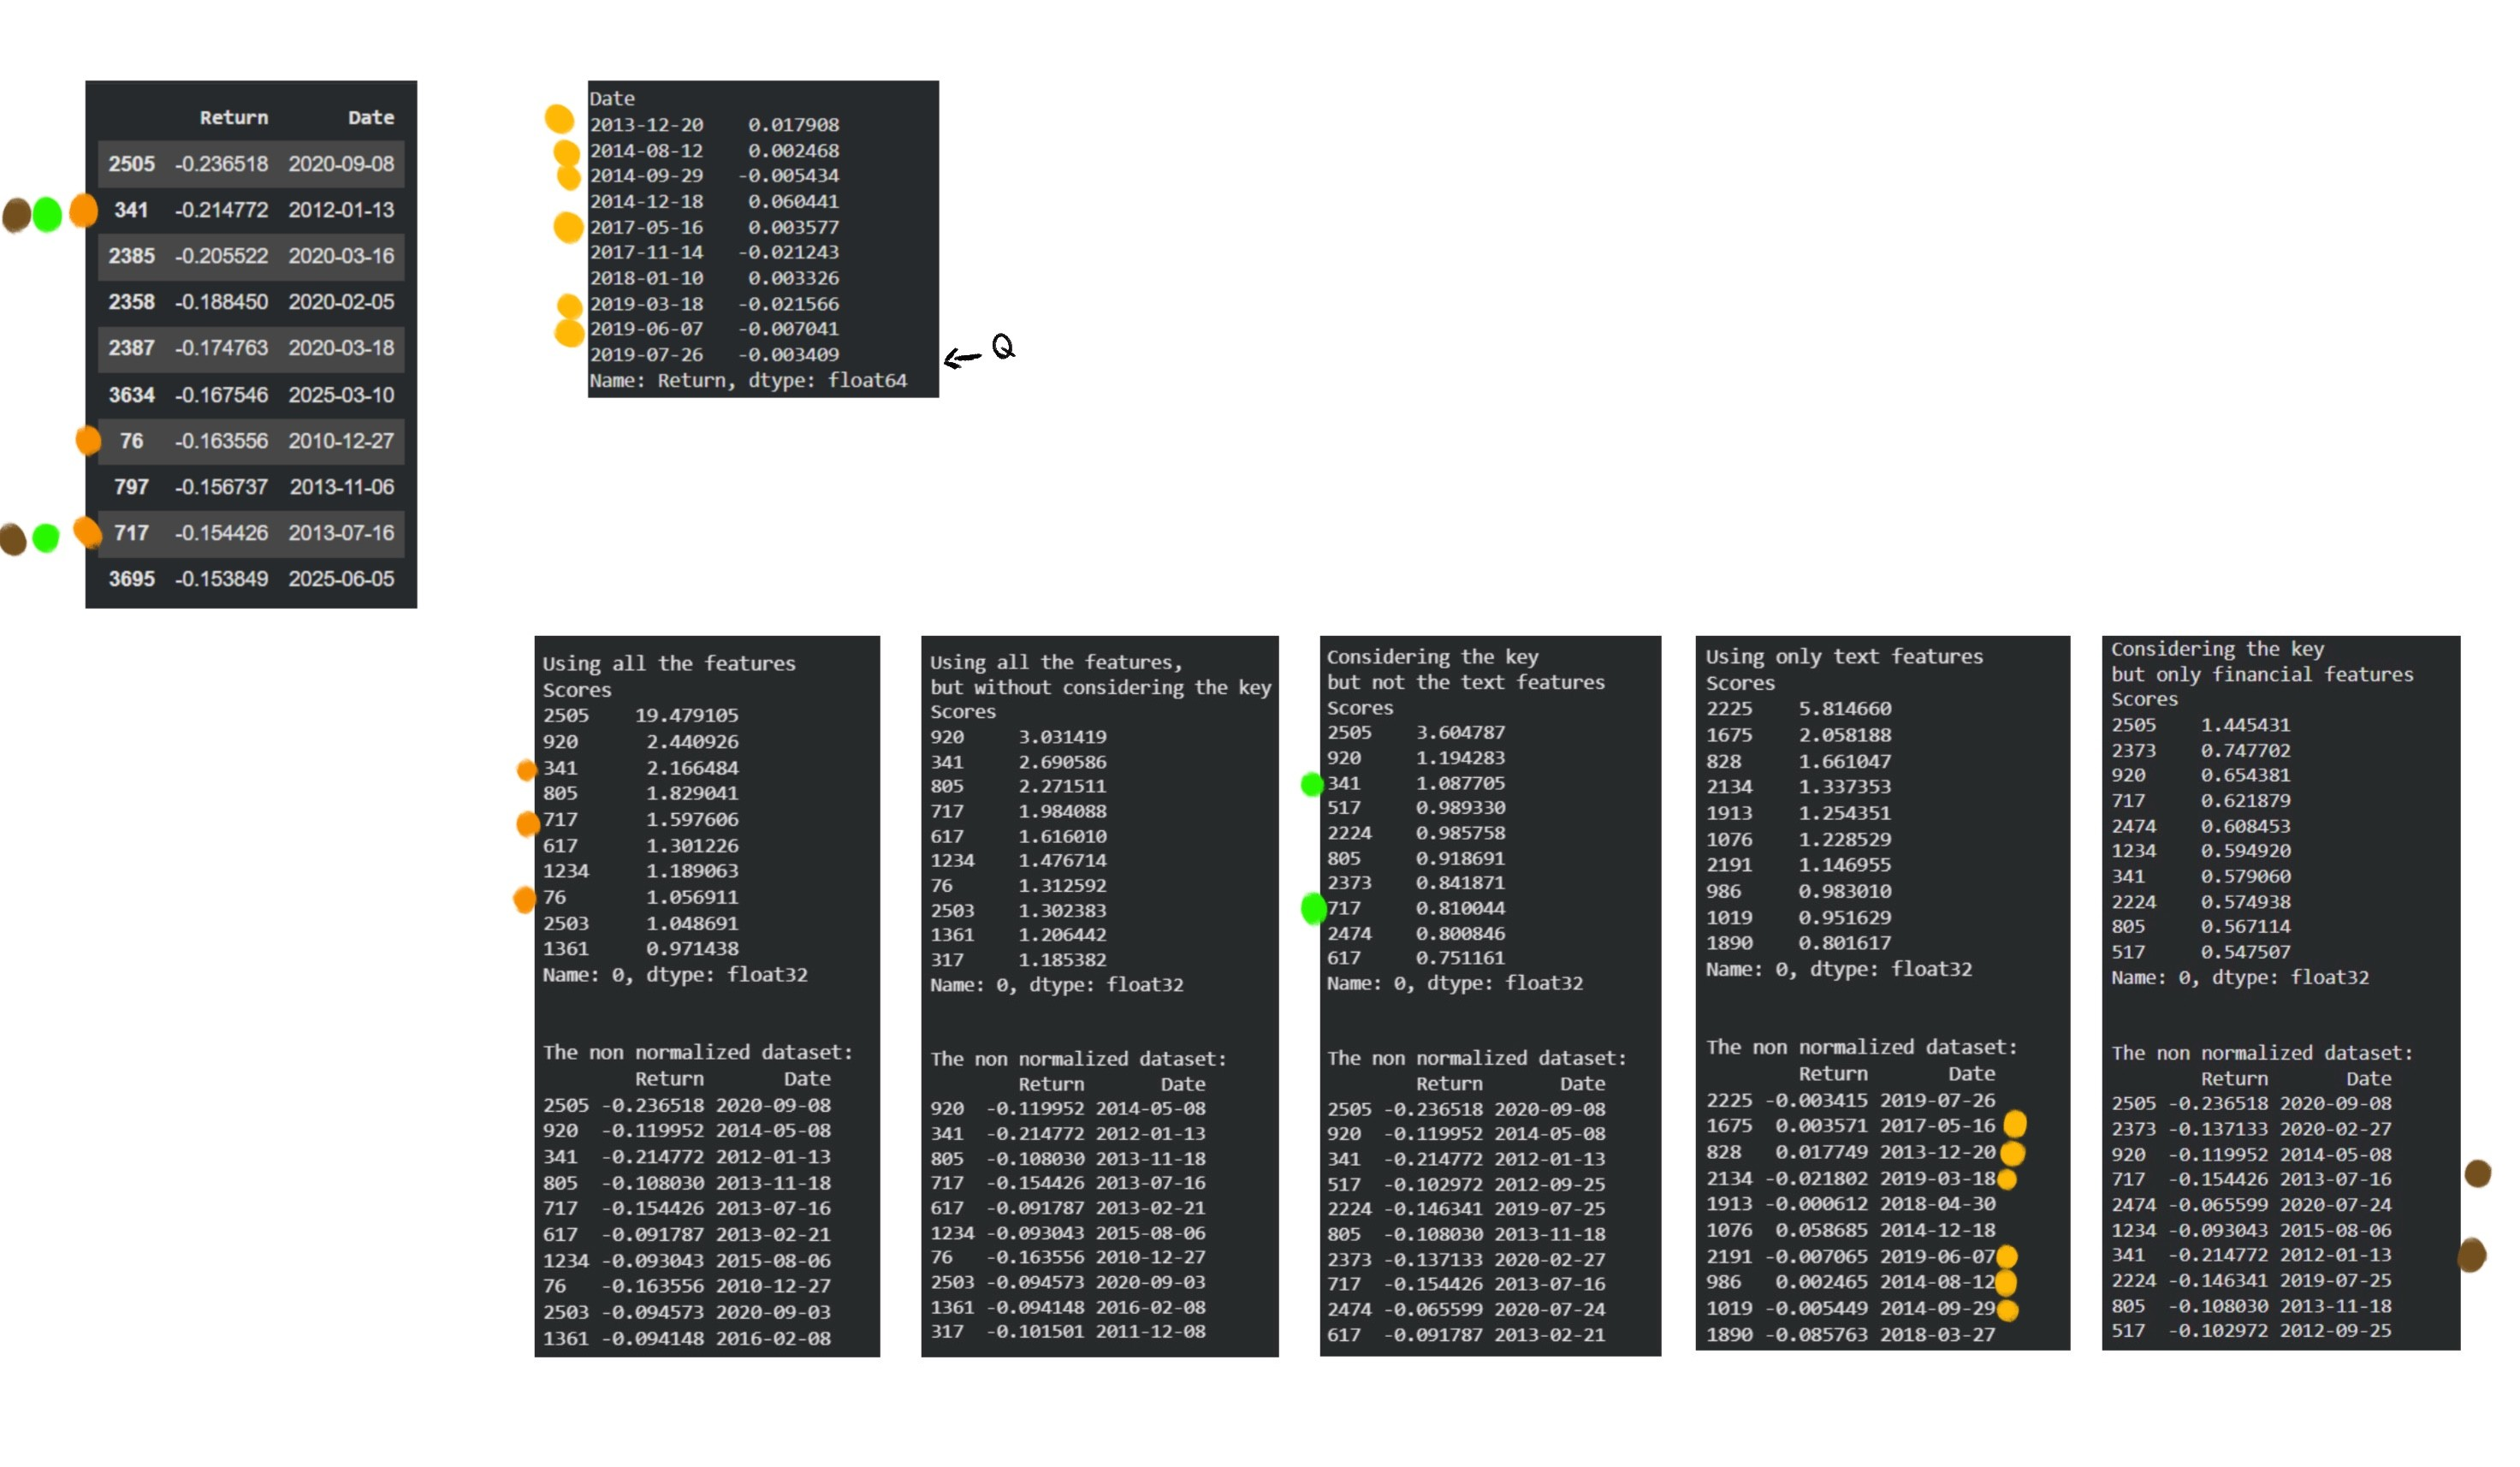

## DotProduct Function for the transformer architecture

In [335]:
#From d2l.ai
def masked_softmax(X, valid_lens):
    """Perform softmax operation by masking elements on the last axis."""
    # X: 3D tensor, valid_lens: 1D or 2D tensor
    def _sequence_mask(X, valid_len, value=0):
        maxlen = X.size(1)
        mask = torch.arange((maxlen), dtype=torch.float32,
                            device=X.device)[None, :] < valid_len[:, None]
        X[~mask] = value
        return X

    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # On the last axis, replace masked elements with a very large negative
        # value, whose exponentiation outputs 0
        X = _sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [336]:
#From d2l.ai. I've only changed the output in order to have the attention_weights
class DotProductAttention(nn.Module):
    """Scaled dot product attention."""
    def __init__(self, dropout,temperature):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.temperature=temperature

    # Shape of queries: (batch_size, no. of queries, d)
    # Shape of keys: (batch_size, no. of key-value pairs, d)
    # Shape of values: (batch_size, no. of key-value pairs, value dimension)
    # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / (math.sqrt(d) * self.temperature)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return self.attention_weights, torch.bmm(self.dropout(self.attention_weights), values)

In [337]:
columns= features
d=len(columns)

train_df_tensor=torch.tensor(train_df[columns].values)
train_df_tensor = train_df_tensor.float()

layer_norm=nn.LayerNorm(d)
dataset_norm=layer_norm(train_df_tensor)
# First lets create our q,k,v
q=torch.tensor(dataset_norm).unsqueeze(0)
k=torch.tensor(dataset_norm).unsqueeze(0)
v=torch.tensor(dataset_norm).unsqueeze(0)

# Why unsqueeze?
# All the functions are going to recieve tensors of dimension: (batch size, no. of queries, d)
# On our original data we missed the first argument, thanks to unsqueeze we now have batch size = 1

#Check the shapes
q.shape,k.shape,v.shape

(torch.Size([1, 3338, 73]),
 torch.Size([1, 3338, 73]),
 torch.Size([1, 3338, 73]))

In [338]:
DotProduct=DotProductAttention(0,1) #Dropout: zero
attention,values=DotProduct(q,k,v,None)


Each row is multiplied by another, that's why we have that dimension, which is the length of the train_df

In [339]:
#We may want to seek for the attention score of the row n, which is the attention of that row compared with all the rows of the dataset.
#We should obtain the same result seen at first
pd.DataFrame(attention[0][2505].T.numpy())[0].sort_values(ascending=False).head(10)*100

,0
2505,22.286091
341,2.356816
76,1.962878
805,1.921691
920,1.676952
717,1.463420
2503,1.207601
1361,0.992199
801,0.959176
317,0.900817


It is indeed the same

The attention function is multiplied by the values, so the model later on will use the output, which preserve the original shape

In [340]:
values.shape

torch.Size([1, 3338, 73])

In [341]:
#Each row is multiplied by the attention score calculated before
#So the above value is:
(attention[0]@v[0])[2505]

tensor([ 5.8711e-01,  1.7592e-01, -3.2645e-02,  2.2314e-01,  1.0619e-02,
        -1.4114e-02,  4.5064e-01,  5.3616e-01, -2.7264e-01,  2.2314e-01,
        -3.1482e-01, -2.2498e+00,  9.6702e-01, -1.0455e-01, -1.3754e-01,
        -1.0657e-01, -1.3511e-01, -5.2515e-01,  2.3935e-01,  3.6487e-01,
         1.6760e-01, -2.2000e+00, -2.1687e+00,  2.4607e-01,  6.2168e-01,
         2.2589e-01, -1.4976e+00,  7.0253e-01,  8.3535e-01,  1.1835e+00,
         7.6091e-01, -2.2521e-01, -3.9068e-01, -3.1012e-01, -2.6492e-01,
         1.9111e-01, -1.7444e-02,  2.8502e-01,  3.2716e-02,  3.6962e-01,
        -9.4594e-02,  1.4620e-01, -2.3049e-02, -3.3660e-02,  8.5231e-04,
         1.3496e-01, -4.1863e-01,  1.1481e-01, -3.3451e-03,  1.5569e-01,
        -1.2816e-01,  4.2648e-02, -8.6610e-02,  1.6916e-01, -2.4011e-01,
         1.3445e-01,  2.6204e-02,  1.3422e-01, -2.1348e-02,  1.2048e-01,
        -8.2232e-02,  3.6324e-01, -1.7261e-01, -9.5697e-02, -1.8609e-01,
         1.2156e-01, -5.9475e-03,  4.1005e-01,  1.2

In [342]:
values[0][2505] #It's the same

tensor([ 5.8711e-01,  1.7592e-01, -3.2645e-02,  2.2314e-01,  1.0619e-02,
        -1.4114e-02,  4.5064e-01,  5.3616e-01, -2.7264e-01,  2.2314e-01,
        -3.1482e-01, -2.2498e+00,  9.6702e-01, -1.0455e-01, -1.3754e-01,
        -1.0657e-01, -1.3511e-01, -5.2515e-01,  2.3935e-01,  3.6487e-01,
         1.6760e-01, -2.2000e+00, -2.1687e+00,  2.4607e-01,  6.2168e-01,
         2.2589e-01, -1.4976e+00,  7.0253e-01,  8.3535e-01,  1.1835e+00,
         7.6091e-01, -2.2521e-01, -3.9068e-01, -3.1012e-01, -2.6492e-01,
         1.9111e-01, -1.7444e-02,  2.8502e-01,  3.2716e-02,  3.6962e-01,
        -9.4594e-02,  1.4620e-01, -2.3049e-02, -3.3660e-02,  8.5231e-04,
         1.3496e-01, -4.1863e-01,  1.1481e-01, -3.3451e-03,  1.5569e-01,
        -1.2816e-01,  4.2648e-02, -8.6610e-02,  1.6916e-01, -2.4011e-01,
         1.3445e-01,  2.6204e-02,  1.3422e-01, -2.1348e-02,  1.2048e-01,
        -8.2232e-02,  3.6324e-01, -1.7261e-01, -9.5697e-02, -1.8609e-01,
         1.2156e-01, -5.9475e-03,  4.1005e-01,  1.2

## Temperature scaling

As you can see, the model gives a too high score to the first value, that's why I added the tempearature in order to try to rescale it and distribuit it better.Another idea would have been remove the diagonal rows, but it would have removed the current day, which is not ideal

In [343]:
DotProduct=DotProductAttention(0,10)
attention,values=DotProduct(q,k,v,None)

In [344]:
pd.DataFrame(attention[0][2505].T.numpy())[0].sort_values(ascending=False).head(10)
#Just was only for test it, but just to give the idea

,0
2505,0.000702
341,0.000561
76,0.000551
805,0.000550
920,0.000542
717,0.000535
2503,0.000525
1361,0.000514
801,0.000513
317,0.000509


## MultiHead Attention

In [345]:
#It is from d2l, I've changed also here the output to have the attention weights
class MultiHeadAttention(d2l.Module):
    """Multi-head attention."""
    def __init__(self, num_hiddens, num_heads, dropout,temperature, bias=False, **kwargs):
        super().__init__()
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout,temperature)
        self.W_q = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_k = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_v = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_o = nn.LazyLinear(num_hiddens, bias=bias)

    def transpose_qkv(self, X):
        """Transposition for parallel computation of multiple attention heads.

        Defined in :numref:`sec_multihead-attention`"""
        # Shape of input X: (batch_size, no. of queries or key-value pairs,
        # num_hiddens). Shape of output X: (batch_size, no. of queries or
        # key-value pairs, num_heads, num_hiddens / num_heads)
        X = X.reshape(X.shape[0], X.shape[1], self.num_heads, -1)
        # Shape of output X: (batch_size, num_heads, no. of queries or key-value
        # pairs, num_hiddens / num_heads)
        X = X.permute(0, 2, 1, 3)
        # Shape of output: (batch_size * num_heads, no. of queries or key-value
        # pairs, num_hiddens / num_heads)
        return X.reshape(-1, X.shape[2], X.shape[3])


    def transpose_output(self, X):
        """Reverse the operation of transpose_qkv.

        Defined in :numref:`sec_multihead-attention`"""
        X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2])
        X = X.permute(0, 2, 1, 3)
        return X.reshape(X.shape[0], X.shape[1], -1)

    def forward(self, queries, keys, values, valid_lens):
        # Shape of queries, keys, or values:
        # (batch_size, no. of queries or key-value pairs, num_hiddens)
        # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
        # After transposing, shape of output queries, keys, or values:
        # (batch_size * num_heads, no. of queries or key-value pairs,
        # num_hiddens / num_heads)
        queries = self.transpose_qkv(self.W_q(queries))
        keys = self.transpose_qkv(self.W_k(keys))
        values = self.transpose_qkv(self.W_v(values))

        if valid_lens is not None:
            # On axis 0, copy the first item (scalar or vector) for num_heads
            # times, then copy the next item, and so on
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        # Shape of output: (batch_size * num_heads, no. of queries,
        # num_hiddens / num_heads)
        weights,output = self.attention(queries, keys, values, valid_lens) #PerchÃ¨ prima l'avevo modificato per avere gli attention weights
        # Shape of output_concat: (batch_size, no. of queries, num_hiddens)
        output_concat = self.transpose_output(output)
        return weights,self.W_o(output_concat)

Going back to our q,k,v, so to our one batch with all the values.


In [346]:
Multi=MultiHeadAttention(500,2,0,2) #Dimension to feed forward, number of head, dropout, and temperature scaling
w,o=Multi(q,k,v,None)

The MultiHeadAttention class provides as outputs: weight and the attention

In [347]:
print("Attention weights heads shape")
print(w.shape)
print("First head values of the n row:")
print(w[0][100])
print("Second head values of the n row: ")
print( w[1][100] )

Attention weights heads shape
torch.Size([2, 3338, 3338])
First head values of the n row:
tensor([0.0003, 0.0003, 0.0003,  ..., 0.0003, 0.0003, 0.0003],
       grad_fn=<SelectBackward0>)
Second head values of the n row: 
tensor([0.0003, 0.0003, 0.0003,  ..., 0.0003, 0.0003, 0.0002],
       grad_fn=<SelectBackward0>)


With the multihead we loose our original columns. They are projected into d_hidden dimension, and then we have the dot product.

At the end, the output still has 3360 rows, but the number of columns is now changed

In [348]:
o.shape

torch.Size([1, 3338, 500])

Lets go in depth

In [349]:
num_heads = 2
num_hiddens=500
bias=False
attention = DotProductAttention(0.5,10)
W_q = nn.LazyLinear(num_hiddens, bias=bias)
W_k = nn.LazyLinear(num_hiddens, bias=bias)
W_v = nn.LazyLinear(num_hiddens, bias=bias)
W_o = nn.LazyLinear(num_hiddens, bias=bias)
#We already have our q,k,v
#First they are projected into their new dimension, which is n_hiddens
queries = Multi.transpose_qkv(W_q(q))
keys = Multi.transpose_qkv(W_k(k))
values = Multi.transpose_qkv(W_v(v))

print("The new shapes are: ")
print("From q:")
print(q.shape)
print("To")
print(queries.shape)
print("Why 250?")
print("num_hiddens/num_heads")

The new shapes are: 
From q:
torch.Size([1, 3338, 73])
To
torch.Size([2, 3338, 250])
Why 250?
num_hiddens/num_heads


In [350]:
#More in depth
X = queries.reshape(q.shape[0], q.shape[1], num_heads, -1)
print(X.shape)
X = X.permute(0, 2, 1, 3)
print(X.shape)
X=X.reshape(-1, X.shape[2], X.shape[3])
print(X.shape)
print("Each head is going to work with:")
X[0].shape

torch.Size([1, 3338, 2, 250])
torch.Size([1, 2, 3338, 250])
torch.Size([2, 3338, 250])
Each head is going to work with:


torch.Size([3338, 250])

So the attention between q and k is going to be calculated using [3338][250]*[250][3338] -> output of the first head is [3338,3338].

The same for the second head.

Each head is going to give as output [3338,3338], so we are going to have [2,3338,3338], but using only d_hiddens/n_heads to look for the similarity

The number of features used to look for similarity from each head is d_hiddens/n_heads

In [351]:
weights,output=Multi.attention(X,X,X)

In [352]:
#each head calculated the weights for each row using 250 columns, then each head multiplied its weight by its part of the division
weights.shape,output.shape

(torch.Size([2, 3338, 3338]), torch.Size([2, 3338, 250]))

In [353]:
print("Before: ")
print(output.shape)
print("Then: ")
print(Multi.transpose_output(output).shape)
print("Check how it does it")
print(output[0][0][0])
print(output[1][0][0])

#The first head calculated the attention using the first n_hiddens/n_head and seq_length row
#The second head calculated the attention using the second n_hiddens/n_head and seq_length row
#Then they are multiplied by the values, which also is going to have seq_length rows and n_hiddens/n_head columns
#But then using the transpose_output function they are going to be concatenated in order to have (batch_size,seq_length,n_hiddens)
#Indeed, the n_hiddens/n_heads row value of the combined output is the first of the second single head

print("Which is: ")
print(Multi.transpose_output(output)[0][0][250])

Before: 
torch.Size([2, 3338, 250])
Then: 
torch.Size([1, 3338, 500])
Check how it does it
tensor(0.0959, grad_fn=<SelectBackward0>)
tensor(0.1062, grad_fn=<SelectBackward0>)
Which is: 
tensor(0.1062, grad_fn=<SelectBackward0>)


The actual output is the concatenation of those values

At the end, the nn.MultiheadAttention class gives as output the weight calulated by each head and the output already concatenated.

The MultiHeadAttention class gives as output:

weights: [2,3338,3338]

outputs: [1,3338,500]

For this example we have used one batch, but with more than one, we are going to have outputs with size
(batch_size * num_heads, no. of queries, num_hiddens / num_heads)

## The transformer EncoderBlock

What done above is going to be repeted several times
So:
- MultiHeadAttention
- AddNorm
- PositionWiseFFN ->each row is going to be projected to a higher dimension to study the relationship between each "column"
- AddNorm again


This is going to be repeted number of layers time

In [354]:
class AddNorm(nn.Module):
    """Residual connection followed by layer normalization."""
    def __init__(self, num_hiddens, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(num_hiddens,bias=False)

    def forward(self, X, Y):
        return self.ln(X + self.dropout(Y))

class PositionWiseFFN(nn.Module):
    """Two-layer feed-forward network applied to each token."""
    def __init__(self, num_hiddens, ffn_num_hiddens, dropout=0.1):
        super().__init__()
        self.ffn = nn.Sequential(
            nn.Linear(num_hiddens, ffn_num_hiddens,bias=False),
            nn.GELU(), #I've changed it from Relu
            nn.Dropout(dropout),
            nn.Linear(ffn_num_hiddens, num_hiddens,bias=False)
        )

    def forward(self, X):
        return self.ffn(X)

#From d2l.ai class, but I had som problem with It. I've asked Claude AI, this was the response:
# Nella classe PositionalEncoding, hai definito la matrice self.P come un normale tensore torch.zeros(...). Questo fa sÃ¬ che ad ogni forward pass tu debba forzarlo sul device con .to(X.device).
# Oltre a causare leggeri rallentamenti, PyTorch non salverÃ  questo tensore se esporti il modello.
# Soluzione: Registra la matrice delle posizioni come "buffer" nel metodo __init__. In questo modo verrÃ  spostato automaticamente quando chiami model.to(device).

class PositionalEncoding(nn.Module):
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        P[:, :, 0::2] = torch.sin(X)
        P[:, :, 1::2] = torch.cos(X)

        self.register_buffer('P', P) #The fix made by CLAUDE AI

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)  # Ensure P is on the same device as X
        return self.dropout(X)


### PositionWiseFFN
How It works

In [355]:
X=Multi.transpose_output(output)
X.shape

torch.Size([1, 3338, 500])

In [356]:
ffn_num_hiddens=1000
dropout=0
PositionWise=PositionWiseFFN(num_hiddens,ffn_num_hiddens, dropout)
Projection=PositionWise(X)
Projection.shape #It mantains the original shape at the end

torch.Size([1, 3338, 500])

In [357]:
#What happens inside
Linear=nn.Linear(num_hiddens, ffn_num_hiddens)
Relu=nn.ReLU()
Gelu=nn.GELU
Drop=nn.Dropout(dropout)
LinearSqz=nn.Linear(ffn_num_hiddens, num_hiddens)
print(Linear(X).shape)
print(Linear(X)[0][0][0])
print("Relu take the positive, otherwise zero")
print(Relu(Linear(X)[0][0][0]))
print("While Gelu allows small negative values")
print(Gelu(Linear(X)[0][0][0]))
#Then we dropout it and reduce the dimensionality

torch.Size([1, 3338, 1000])
tensor(0.0461, grad_fn=<SelectBackward0>)
Relu take the positive, otherwise zero
tensor(0.0461, grad_fn=<ReluBackward0>)
While Gelu allows small negative values
GELU(approximate=tensor(0.0461, grad_fn=<SelectBackward0>))


### AddNorm

In [358]:
addnorm1 = AddNorm(num_hiddens, dropout)
weights,attn_output = attention(X, X, X, None)
X_add_norm= addnorm1(X, attn_output)

In [359]:
X_add_norm.shape

torch.Size([1, 3338, 500])

In [360]:
# X is still going to have the same shape, but it will be given by.
print(X[0][0][0])
print(attn_output[0][0][0])
layer_norm=nn.LayerNorm(X.shape[-1])
out=layer_norm(X[0][0]+attn_output[0][0])
print(out[0])
print(X_add_norm[0][0][0]) #Just to show that It is the same

tensor(0.0959, grad_fn=<SelectBackward0>)
tensor(0.0933, grad_fn=<SelectBackward0>)
tensor(1.2113, grad_fn=<SelectBackward0>)
tensor(1.2113, grad_fn=<SelectBackward0>)


In [361]:
#Why do we need it
x = torch.tensor([X[0][0][0].item()], requires_grad=True)
print(x)
attn = torch.tensor([0.0])   # suppose the attention is zero, which is highly probable as seen in the first examples
out = x + attn
out.backward()
print(f"attention zero:")
print(f"âˆ‚out/âˆ‚x = {x.grad.item():.4f}")

x    = torch.tensor([X[0][0][0].item()],   requires_grad=True)
attn = torch.tensor([0.03], requires_grad=True)

out = x + attn
print(out)
out.backward()
print(f"attention right:")
print(f"âˆ‚out/âˆ‚x    = {x.grad.item():.4f}")


tensor([0.0959], requires_grad=True)
attention zero:
âˆ‚out/âˆ‚x = 1.0000
tensor([0.1259], grad_fn=<AddBackward0>)
attention right:
âˆ‚out/âˆ‚x    = 1.0000


### TransformerEncoderBlock

In [362]:
#From d2l.ai
class TransformerEncoderBlock(nn.Module):
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout=0.1, temperature=1):
        super().__init__()
        self.attention = MultiHeadAttention(num_hiddens=num_hiddens, num_heads=num_heads, dropout=dropout, temperature=temperature)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(num_hiddens, ffn_num_hiddens, dropout)
        self.addnorm2 = AddNorm(num_hiddens, dropout)
    def forward(self, X, valid_lens=None):
        weights, attn_output = self.attention(X,X,X, valid_lens=valid_lens)
        X = self.addnorm1(X, attn_output)
        ffn_output = self.ffn(X)
        X = self.addnorm2(X, ffn_output)
        return weights, X

First we need to project out x into num_hiddens dimension.

Why?

Despite the MultiHeadAttention uses lazylinear so it can take any input dimension and gives an output with num_hiddens dimension,addnorm1, ffn and addnorm2, takes as input only num_hiddens dimension.

At first I thought that it was the nn.MultiheadAttention that projected the input into num_hiddens, but it is actually already done before, then the latter class just keep the dimension


In [363]:
ll=nn.LazyLinear(500,bias=False)
querie=ll(q)

In [364]:
TEB=TransformerEncoderBlock(500,1200,2,0.1,1)
weights_enc,attn_enc=TEB.attention(querie,querie,querie,None)
print(f"First shapes of the encoder, hence the attention: {weights_enc.shape} and the output:{attn_enc.shape}")
querie=TEB.addnorm1(querie,attn_enc)
print(f"The X is now:{querie.shape}, so the same")
ffn_enc=TEB.ffn(querie)
print(f"The X is now:{querie.shape}, still the same")
querie=TEB.addnorm2(querie,ffn_enc)
print(f"The first layer encoder dimension is then: \n for the attention weight: {weights_enc.shape}, for the querie weight {querie.shape}")


First shapes of the encoder, hence the attention: torch.Size([2, 3338, 3338]) and the output:torch.Size([1, 3338, 500])
The X is now:torch.Size([1, 3338, 500]), so the same
The X is now:torch.Size([1, 3338, 500]), still the same
The first layer encoder dimension is then: 
 for the attention weight: torch.Size([2, 3338, 3338]), for the querie weight torch.Size([1, 3338, 500])


That block is going to be repeted number of layers time

In [365]:
encoder_blocks = nn.ModuleList([
    TransformerEncoderBlock(num_hiddens, ffn_num_hiddens, num_heads, dropout, 1)
    for _ in range(2)
])

In [366]:
attentionWeights = [] # Clear the list for each forward pass
for blk in encoder_blocks:
    weights, querie = blk(querie)
    print(weights.shape)
    print(querie.shape)
    attentionWeights.append(weights)

torch.Size([2, 3338, 3338])
torch.Size([1, 3338, 500])
torch.Size([2, 3338, 3338])
torch.Size([1, 3338, 500])


In [367]:
#Each layer has its own attention weight
attentionWeights[0].shape,attentionWeights[1].shape

(torch.Size([2, 3338, 3338]), torch.Size([2, 3338, 3338]))

# Full Transformer Model

In [713]:
class TimeSeriesTransformer(nn.Module):
    """Transformer for multimodal regression on sequences."""
    def __init__(self, D_fin, D_macro, D_text, num_projection=32, num_hiddens=128,
                 num_heads=4, num_layers=4, ffn_num_hiddens=256, dropout=0.1, max_len=2000, temperature=1.0, num_classes=1):
        super().__init__()
        #First, each feature is going to be projected into its new dimension, in order to have equally distributed features
        self.fin_proj   = nn.Linear(D_fin,   num_projection, bias=False)
        self.macro_proj = nn.Linear(D_macro, num_projection, bias=False)
        self.text_proj = nn.Linear(D_text, num_projection, bias=False)

        fusion_dim = num_projection * 3
        #Then the obtained features are going to be normalized together
        self.fusion_ln    = nn.LayerNorm(fusion_dim, bias=False)
        #Then all of them are going to be projected into num_hiddens dimension, the reason is the same explained in the MultiHead Attention class
        self.fusion_proj  = nn.Linear(fusion_dim, num_hiddens, bias=False)
        #As It was projected, I re-normalized
        self.post_proj_ln = nn.LayerNorm(num_hiddens, bias=False)
        #Finally I've added the positional encoding, which is going to be added before the encoder_block
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout, max_len)

        #The X, obtained from the process above is the one which is going to be used in the encoder block

        # Encoder blocks
        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(num_hiddens, ffn_num_hiddens, num_heads, dropout, temperature)
            for _ in range(num_layers)
        ])
        # Finally in order to have a single value as prediction, we need to add the regression head.
        # I've tried with Relu, but it seemed like it ignore the negative returns.
        # Then I've tried with Gelu and Tanh. At the end I've decided to use GELU.
        self.fc_out = nn.Sequential(
            nn.LayerNorm(num_hiddens, bias=False),
            nn.Linear(num_hiddens, num_hiddens // 2, bias=False),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(num_hiddens // 2, num_classes, bias=True)
        )



    def forward(self, fin, macro, text=None):
            fin_emb   = self.fin_proj(fin)
            macro_emb = self.macro_proj(macro)
            text_emb = self.text_proj(text)
            combined = torch.cat([fin_emb, macro_emb, text_emb], dim=-1)

            x = self.fusion_ln(combined)
            x = self.fusion_proj(x)
            x = self.post_proj_ln(x)
            x = self.pos_encoding(x)

            self.attentionWeights = []
            for blk in self.encoder_blocks:
                weights, x = blk(x)
                self.attentionWeights.append(weights)

            last_step = x[:, -1, :] #Here I've decided to use the last step. I've also tried with mean, CLS and Max. This was the one who worked the best
            return self.fc_out(last_step).squeeze(-1),x

# DataLoader

In [778]:
import pandas as pd
import numpy as np

#Create the sequence
def create_sequences(df, fin_features, macro_features, target_col, window_size,
                     text_features=None):
    X_fin, X_macro, y = [], [], []
    X_text = [] if text_features is not None else None

    data_fin    = df[fin_features].values
    data_macro  = df[macro_features].values
    data_target = df[target_col].values
    data_text   = df[text_features].values if text_features is not None else None

    for i in range(window_size, len(df)):
        X_fin.append(data_fin[i-window_size : i+1]) # +1 because we want the current day, as the target was obtained with df_train["Return"].shift(-1)
        X_macro.append(data_macro[i-window_size : i+1])
        y.append(data_target[i])
        X_text.append(data_text[i-window_size : i+1])

    return np.array(X_fin), np.array(X_macro), np.array(X_text), np.array(y)


for df in [train_df, test_df]:
    df.dropna(inplace=True)
    df.drop_duplicates(inplace=True)


WINDOW_SIZE =120

#For each category, we are going to have number of rows equals the window_size and number of columns equals the len of the feature category
#E.g. X_fin_train is goint to have (2438, 901, 28), which is the length of the train_df minus the window_size.
# Each row is going to be the transposed by one step of the previous. The same for the target, which is going to be the 901th row of train_df
# Without the shuffle, we would have had that train_df["Target"][901] == y_train[1], and so on
X_fin_train, X_macro_train, X_text_train, y_train = create_sequences(
    train_df, FIN_FEATURES_ALL, MACRO_FEATURES_ALL, "Target", WINDOW_SIZE,
    text_features=TEXT_FEATURES_ALL
)

test_input_df = pd.concat(
    [train_df.tail(WINDOW_SIZE), test_df],
    ignore_index=True
)

X_fin_test, X_macro_test, X_text_test, y_test = create_sequences(
    test_input_df, FIN_FEATURES_ALL, MACRO_FEATURES_ALL, "Target", WINDOW_SIZE,
    text_features=TEXT_FEATURES_ALL
)

print(f"Train: {X_fin_train.shape}")
print(f"Test:  {X_fin_test.shape}")

from torch.utils.data import TensorDataset, DataLoader
import torch

def build_dataloaders(X_fin_train, X_macro_train, y_train,
                      X_fin_test,  X_macro_test,  y_test,
                      batch_size=32,
                      X_text_train=None, X_text_test=None):

    train_tensors = [
        torch.tensor(X_fin_train,   dtype=torch.float32),
        torch.tensor(X_macro_train, dtype=torch.float32),
        torch.tensor(X_text_train, dtype=torch.float32)
    ]
    test_tensors = [
        torch.tensor(X_fin_test,    dtype=torch.float32),
        torch.tensor(X_macro_test,  dtype=torch.float32),
        torch.tensor(X_text_test,   dtype=torch.float32)
    ]

    train_tensors.append(torch.tensor(y_train, dtype=torch.float32))
    test_tensors.append(torch.tensor(y_test,   dtype=torch.float32))

    train_loader = DataLoader(TensorDataset(train_tensors[0], train_tensors[1], train_tensors[2], train_tensors[3]),
                              batch_size=batch_size, shuffle=True,  drop_last=True)
    test_loader  = DataLoader(TensorDataset(test_tensors[0], test_tensors[1], test_tensors[2], test_tensors[3]),
                              batch_size=batch_size, shuffle=False, drop_last=False)
    return train_loader, test_loader


train_loader, test_loader = build_dataloaders(
    X_fin_train, X_macro_train, y_train,
    X_fin_test,  X_macro_test,  y_test,
    batch_size=8, #The smaller the batch, the better seemed to work
    X_text_train=X_text_train,
    X_text_test=X_text_test
)

#Each batch is going to have dimension torch.Size([16, 901, len(category_feature)])


Train: (3218, 121, 28)
Test:  (373, 121, 28)


# Train the model

In [793]:
D_fin   = len(FIN_FEATURES_ALL)
D_macro = len(MACRO_FEATURES_ALL)
D_text=  len(TEXT_FEATURES_ALL)
D_fin+D_macro+D_text

69

In [794]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TimeSeriesTransformer(
    D_fin=D_fin,
    D_macro=D_macro,
    D_text=D_text,
    num_projection=8,#->8*3
    num_hiddens=24, #-> from 8*3 to 32
    num_heads=2,
    num_layers=2,
    ffn_num_hiddens=64,
    dropout=0.30,
    temperature=1,
    max_len=2000
).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05,
)

## Training step by step

In [795]:
fin, macro, text, y = next(iter(train_loader))
fin, macro, text, y = fin.to(device), macro.to(device), text.to(device), y.to(device)

print(f"fin shape:     {fin.shape}")
print(f"macro shape:   {macro.shape}")
print(f"text shape:    {text.shape}")
print(f"y shape:       {y.shape}")

fin shape:     torch.Size([8, 121, 28])
macro shape:   torch.Size([8, 121, 11])
text shape:    torch.Size([8, 121, 30])
y shape:       torch.Size([8])


In [796]:
fin_emb   = model.fin_proj(fin)
macro_emb = model.macro_proj(macro)
text_emb  = model.text_proj(text)
print(f"fin_emb shape:   {fin_emb.shape}")
print(f"macro_emb shape: {macro_emb.shape}")
print(f"text_emb shape:  {text_emb.shape}")

combined = torch.cat([fin_emb, macro_emb, text_emb], dim=-1)
print(f"Combined shape: {combined.shape}")  # (batch, seq, num_projection*3)

#Normalization
x = model.fusion_ln(combined)
print(f"After fusion_ln: {x.shape}")        # (batch, seq, num_projection*3)

# Projection to num_hiddens
x = model.fusion_proj(x)
print(f"After fusion_proj: {x.shape}")      # (batch, seq, num_hiddens)

# Normalization after the projection
x = model.post_proj_ln(x)
print(f"After post_proj_ln: {x.shape}")     # (batch, seq, num_hiddens)

# Positional encoding
x = model.pos_encoding(x)
print(f"After pos_encoding: {x.shape}")     # (batch, seq, num_hiddens)

fin_emb shape:   torch.Size([8, 121, 8])
macro_emb shape: torch.Size([8, 121, 8])
text_emb shape:  torch.Size([8, 121, 8])
Combined shape: torch.Size([8, 121, 24])
After fusion_ln: torch.Size([8, 121, 24])
After fusion_proj: torch.Size([8, 121, 24])
After post_proj_ln: torch.Size([8, 121, 24])
After pos_encoding: torch.Size([8, 121, 24])


The x which is going to be fed to the encoder block has shape [8, 121, 24] #Batch size, seq_length, num_hiddens

In [797]:
model.attentionWeights = []
for blk in model.encoder_blocks:
    weights, x = blk(x)
    print(weights.shape)
    print(x.shape)
    model.attentionWeights.append(weights)


torch.Size([16, 121, 121])
torch.Size([8, 121, 24])
torch.Size([16, 121, 121])
torch.Size([8, 121, 24])


In [798]:
model.attentionWeights[0].shape #First layer attentions
model.attentionWeights[1].shape #Second layer attentions
#Why 16?
#Number of head * batch size

torch.Size([16, 121, 121])

In [799]:
print(f"min attention weight: {weights.min()}")
print(f"max attention weight: {weights.max()}")
print(f"mean attention weights:{weights.mean()}")

min attention weight: 0.001570792286656797
max attention weight: 0.034787796437740326
mean attention weights:0.00826446246355772


### The output of the model

In [800]:
print(x.shape)
last_step = x[:, -1, :]
print(last_step.shape)
#We take only the last step.
#Usually, when we have a casual mask, the last token is the only one that have seen all the sequence. So it somehow summarize the whole sequence.
#I've tried with the casual mask, it seems like the attention is too concentrated and the model "collapse".
#I've also tried with CLS, but was the worst approach.
#With the mean it seemed like the model predicted only zero
#At the end I've decided to keep  the last_step, because is the one that whatched all the series and predict the next day return.
#Also the previous steps watch the whole sequence, maybe they also contribute to changes their rapresentation in order for the last step to better predict the next day return

torch.Size([8, 121, 24])
torch.Size([8, 24])


In [801]:
output = model.fc_out(last_step)

In [802]:
output.shape #For each batch we have the prediction

torch.Size([8, 1])

In [803]:
def directional_accuracy(y_true, y_pred):
    same_sign = (np.sign(y_true) == np.sign(y_pred)).sum()
    total = len(y_true)
    accuracy = same_sign / total
    threshold = np.percentile(np.abs(y_true), 95)
    big_moves_mask = np.abs(y_true) > threshold
    big_accuracy = (np.sign(y_true[big_moves_mask]) == np.sign(y_pred[big_moves_mask])).sum() / big_moves_mask.sum()

    print(f"Accuratezza Direzionale Totale: {accuracy:.2%}")
    print(f"Accuratezza nei Grandi Movimenti (Outliers): {big_accuracy:.2%}")



In [804]:
loss_fn=nn.MSELoss()

# Training

Accuratezza Direzionale Totale: 50.13%
Accuratezza nei Grandi Movimenti (Outliers): 52.63%
Epoch [001/250] Loss: T:1.02201 V:1.43649 | Best: ep.1 (1.43649) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 49.33%
Accuratezza nei Grandi Movimenti (Outliers): 47.37%
Epoch [002/250] Loss: T:1.00541 V:1.42368 | Best: ep.2 (1.42368) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 47.18%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [003/250] Loss: T:1.00113 V:1.42065 | Best: ep.3 (1.42065) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 47.45%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [004/250] Loss: T:0.98966 V:1.41811 | Best: ep.4 (1.41811) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 49.87%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [005/250] Loss: T:0.98893 V:1.41710 | Best: ep.5 (1.41710) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 49.06%
Accuratezza nei Grandi Mov

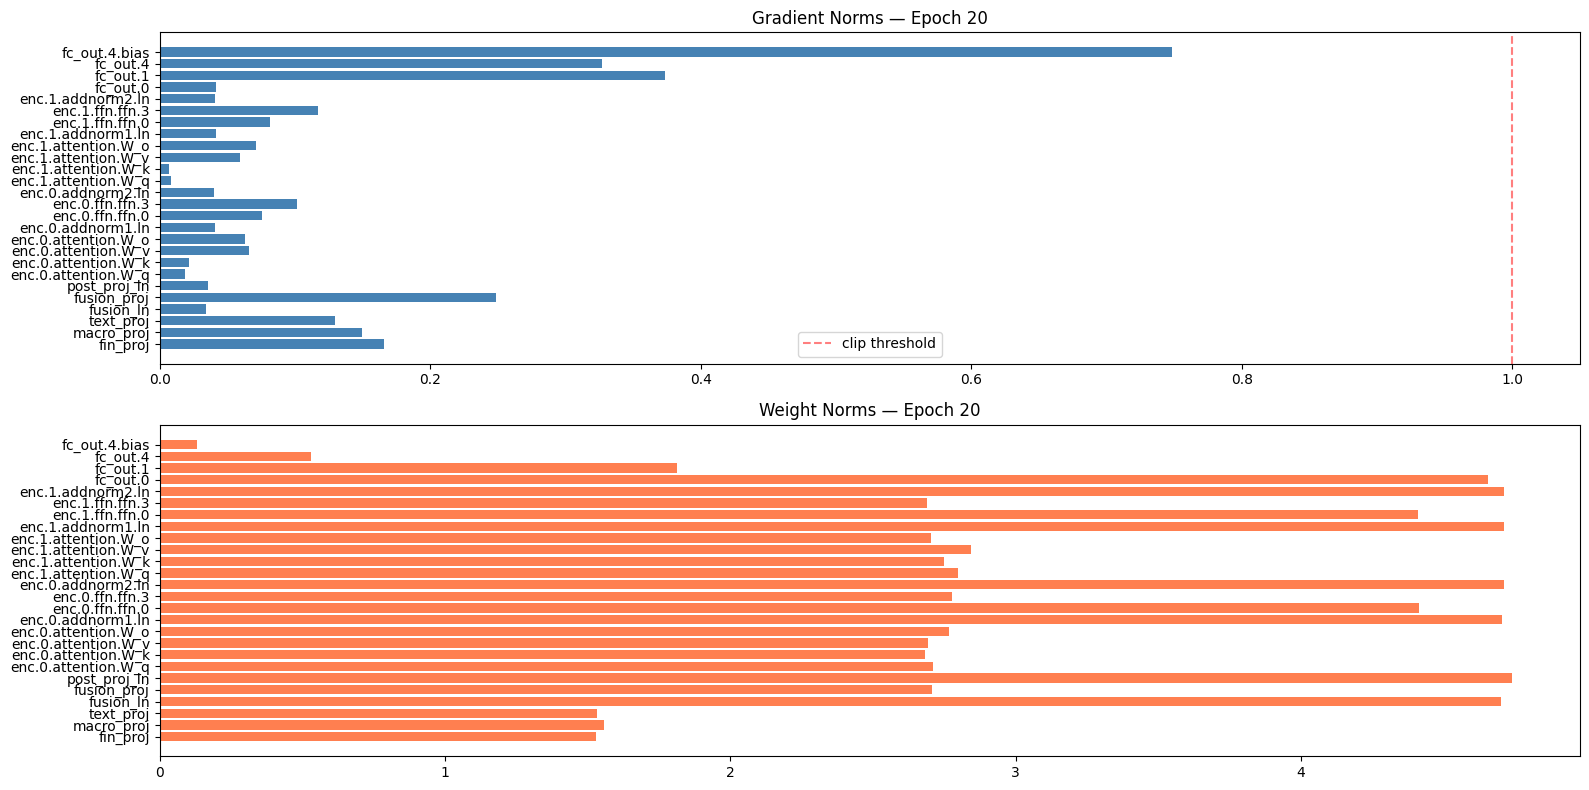

Accuratezza Direzionale Totale: 50.94%
Accuratezza nei Grandi Movimenti (Outliers): 73.68%
Epoch [020/250] Loss: T:0.97397 V:1.41763 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 50.67%
Accuratezza nei Grandi Movimenti (Outliers): 73.68%
Epoch [021/250] Loss: T:0.98259 V:1.41799 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 50.40%
Accuratezza nei Grandi Movimenti (Outliers): 73.68%
Epoch [022/250] Loss: T:0.98216 V:1.41876 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.89%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [023/250] Loss: T:0.96971 V:1.42224 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 51.21%
Accuratezza nei Grandi Movimenti (Outliers): 73.68%
Epoch [024/250] Loss: T:0.98237 V:1.41921 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 50.40%
Accuratezza nei Grandi Mov

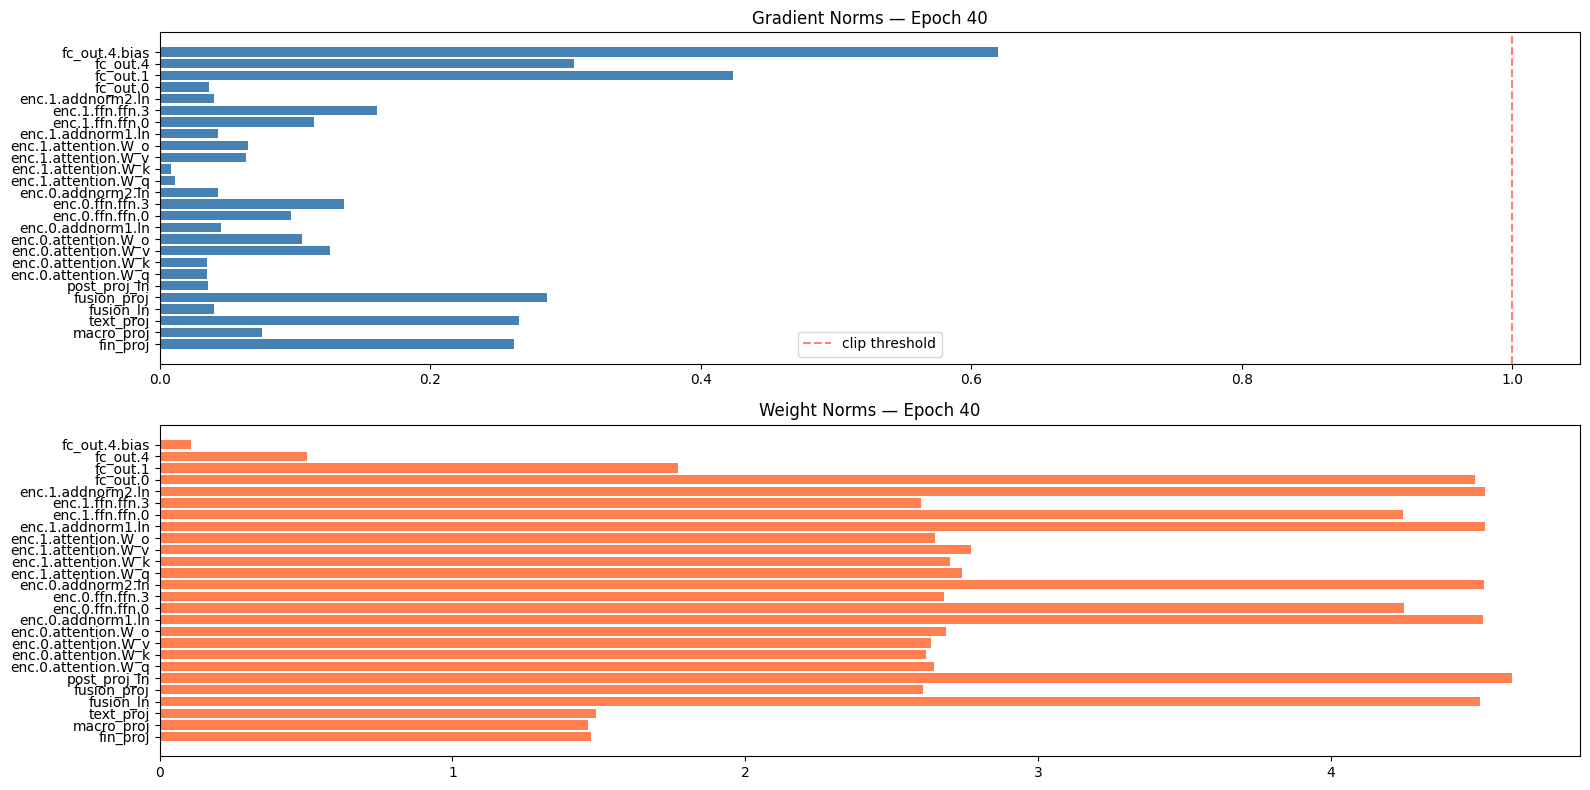

Accuratezza Direzionale Totale: 52.55%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [040/250] Loss: T:0.95854 V:1.42046 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 51.21%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [041/250] Loss: T:0.96104 V:1.41821 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.08%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [042/250] Loss: T:0.96226 V:1.41895 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 52.55%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [043/250] Loss: T:0.95863 V:1.41888 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 52.55%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [044/250] Loss: T:0.96376 V:1.41976 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 50.94%
Accuratezza nei Grandi Mov

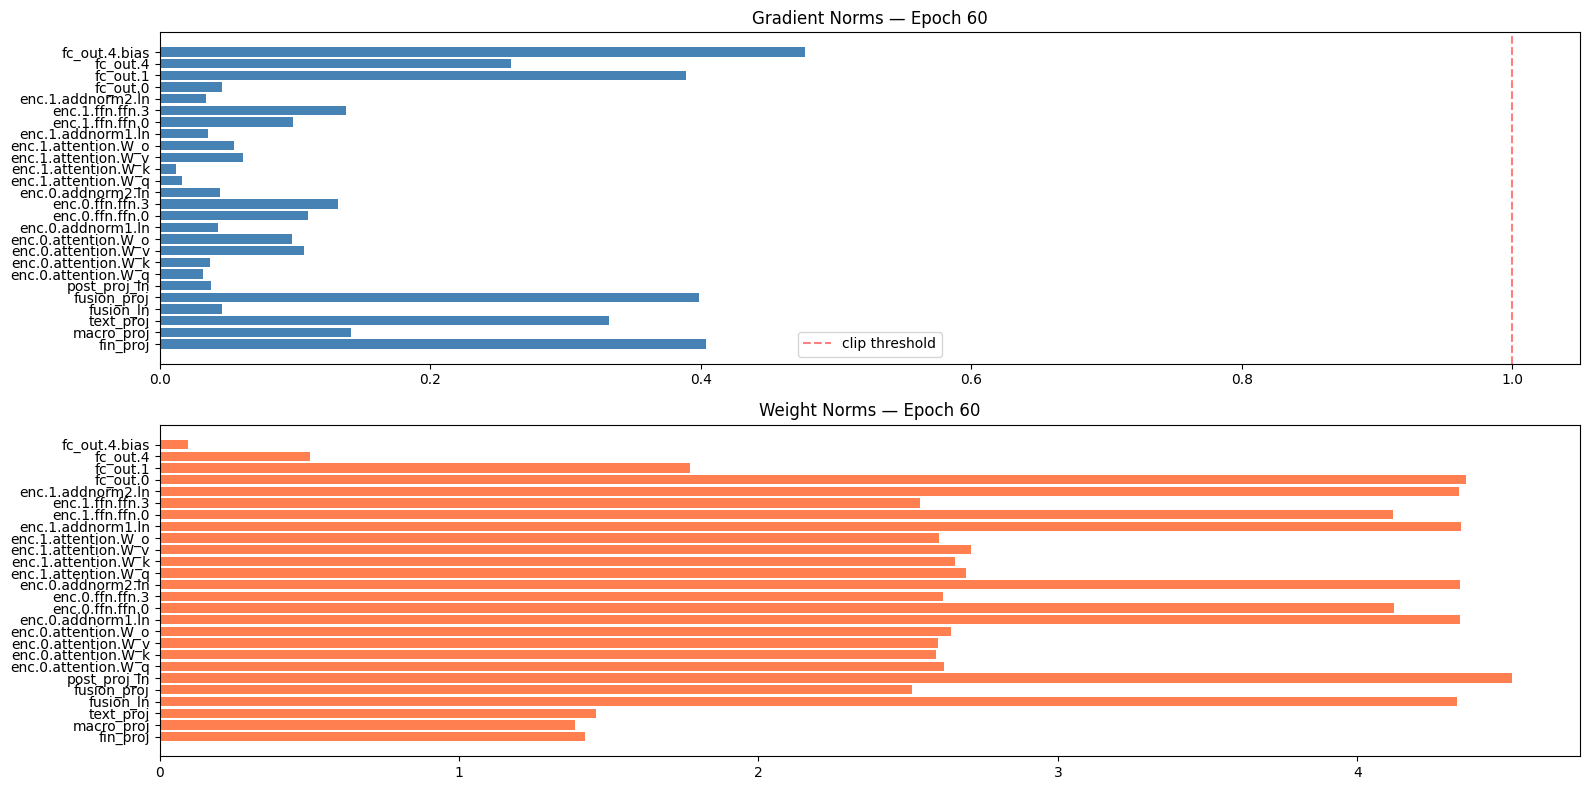

Accuratezza Direzionale Totale: 52.82%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [060/250] Loss: T:0.94903 V:1.42880 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 52.55%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [061/250] Loss: T:0.94850 V:1.43231 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.62%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [062/250] Loss: T:0.94711 V:1.43031 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 52.28%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [063/250] Loss: T:0.94782 V:1.43104 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 52.82%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [064/250] Loss: T:0.95143 V:1.43105 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 52.55%
Accuratezza nei Grandi Mov

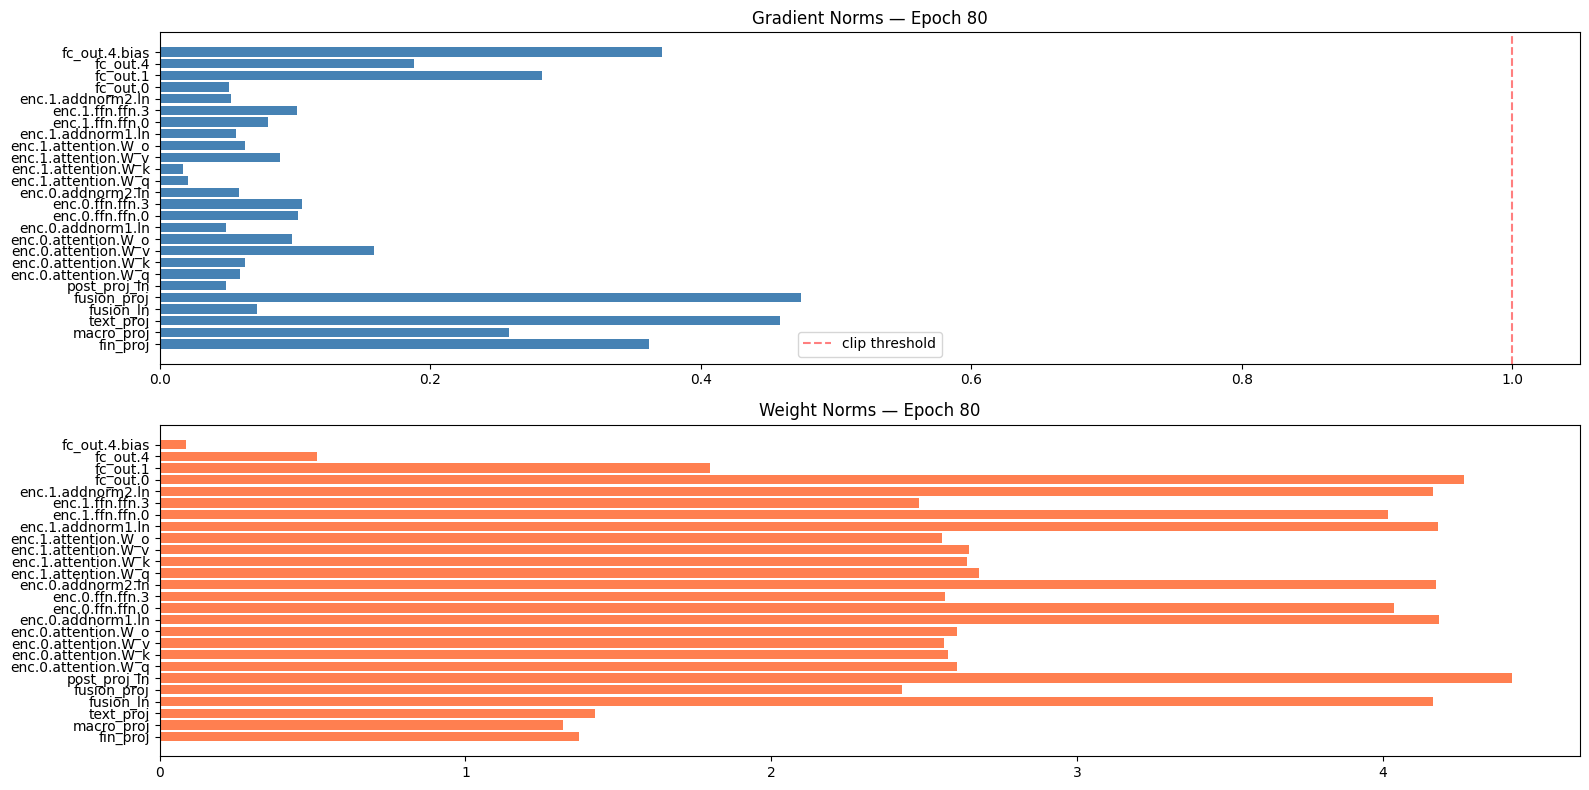

Accuratezza Direzionale Totale: 54.16%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [080/250] Loss: T:0.93038 V:1.43478 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.35%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [081/250] Loss: T:0.93947 V:1.42840 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.69%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [082/250] Loss: T:0.94203 V:1.42687 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.16%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [083/250] Loss: T:0.93137 V:1.43018 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.42%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [084/250] Loss: T:0.93860 V:1.42793 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.62%
Accuratezza nei Grandi Mov

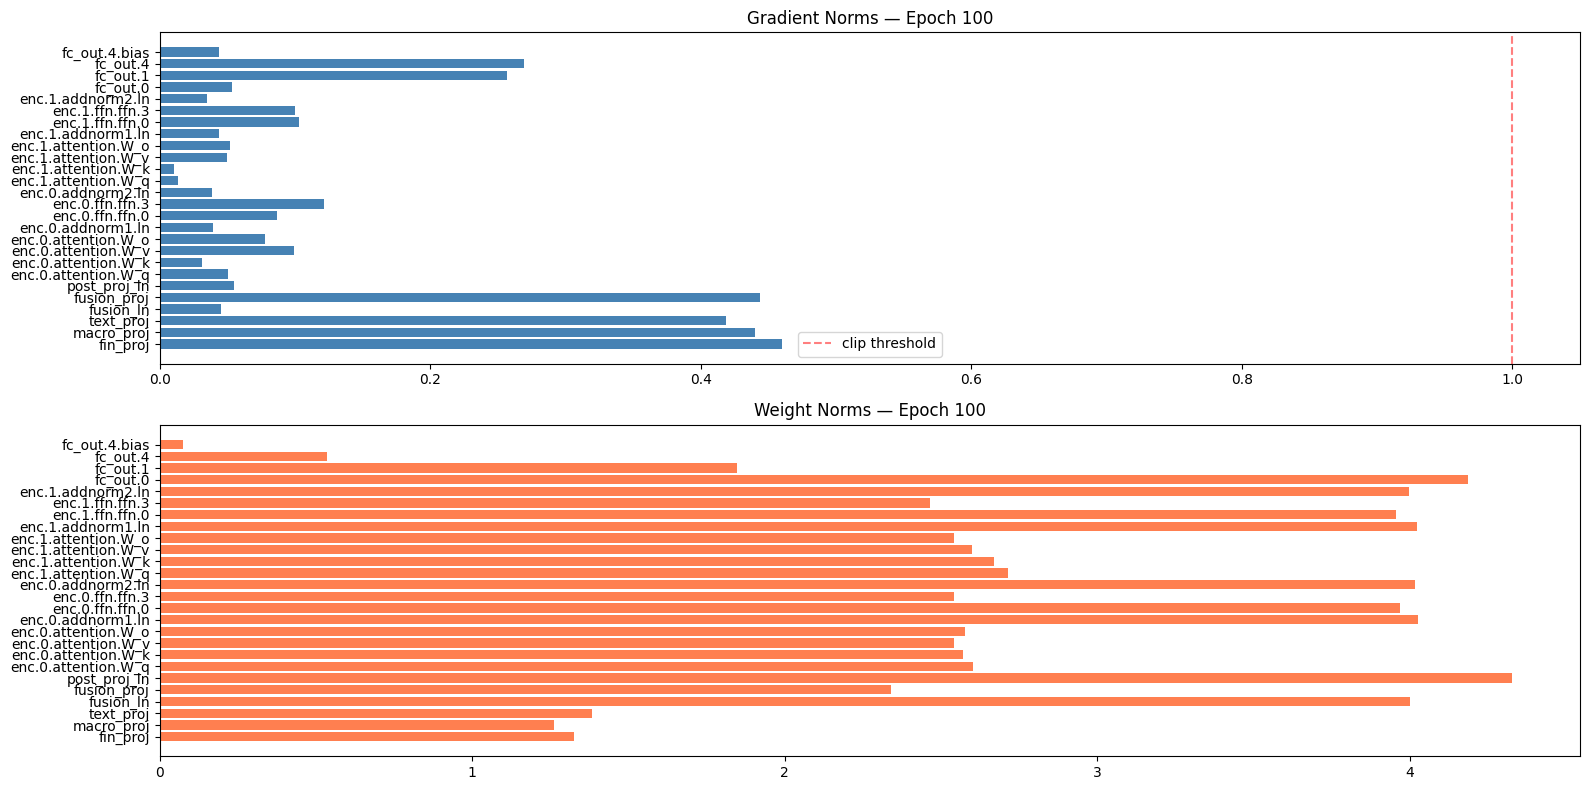

Accuratezza Direzionale Totale: 54.16%
Accuratezza nei Grandi Movimenti (Outliers): 57.89%
Epoch [100/250] Loss: T:0.93138 V:1.42890 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 55.23%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [101/250] Loss: T:0.93140 V:1.42552 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.16%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [102/250] Loss: T:0.92736 V:1.42773 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.69%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [103/250] Loss: T:0.92157 V:1.42141 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.69%
Accuratezza nei Grandi Movimenti (Outliers): 57.89%
Epoch [104/250] Loss: T:0.91885 V:1.42625 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 52.82%
Accuratezza nei Grandi Mov

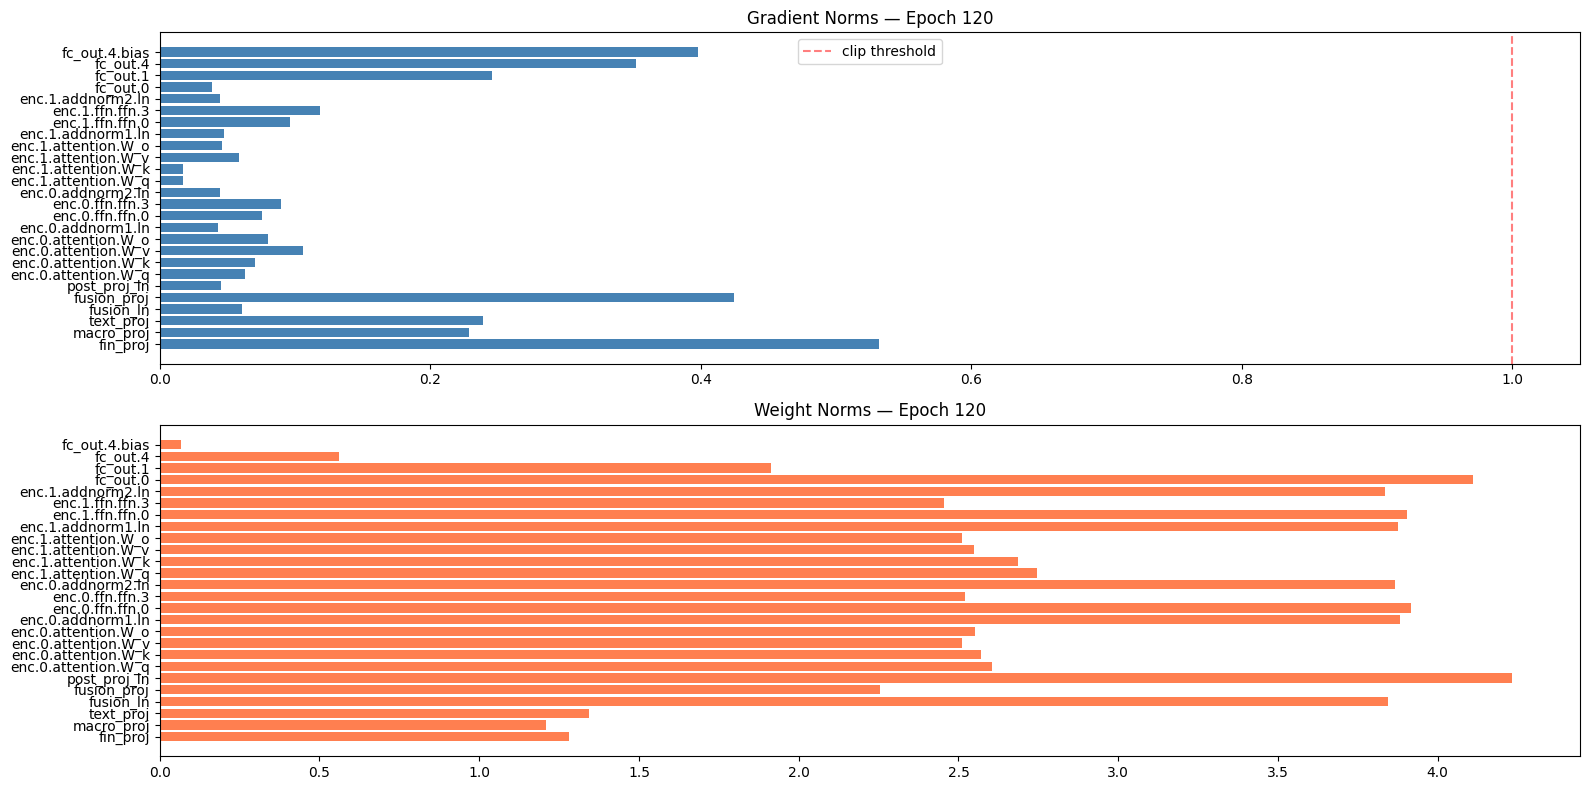

Accuratezza Direzionale Totale: 54.42%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [120/250] Loss: T:0.91228 V:1.43075 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.42%
Accuratezza nei Grandi Movimenti (Outliers): 57.89%
Epoch [121/250] Loss: T:0.90683 V:1.42718 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.96%
Accuratezza nei Grandi Movimenti (Outliers): 57.89%
Epoch [122/250] Loss: T:0.91308 V:1.42511 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.96%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [123/250] Loss: T:0.91330 V:1.42519 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.89%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [124/250] Loss: T:0.90169 V:1.43089 | Best: ep.8 (1.41611) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.16%
Accuratezza nei Grandi Mov

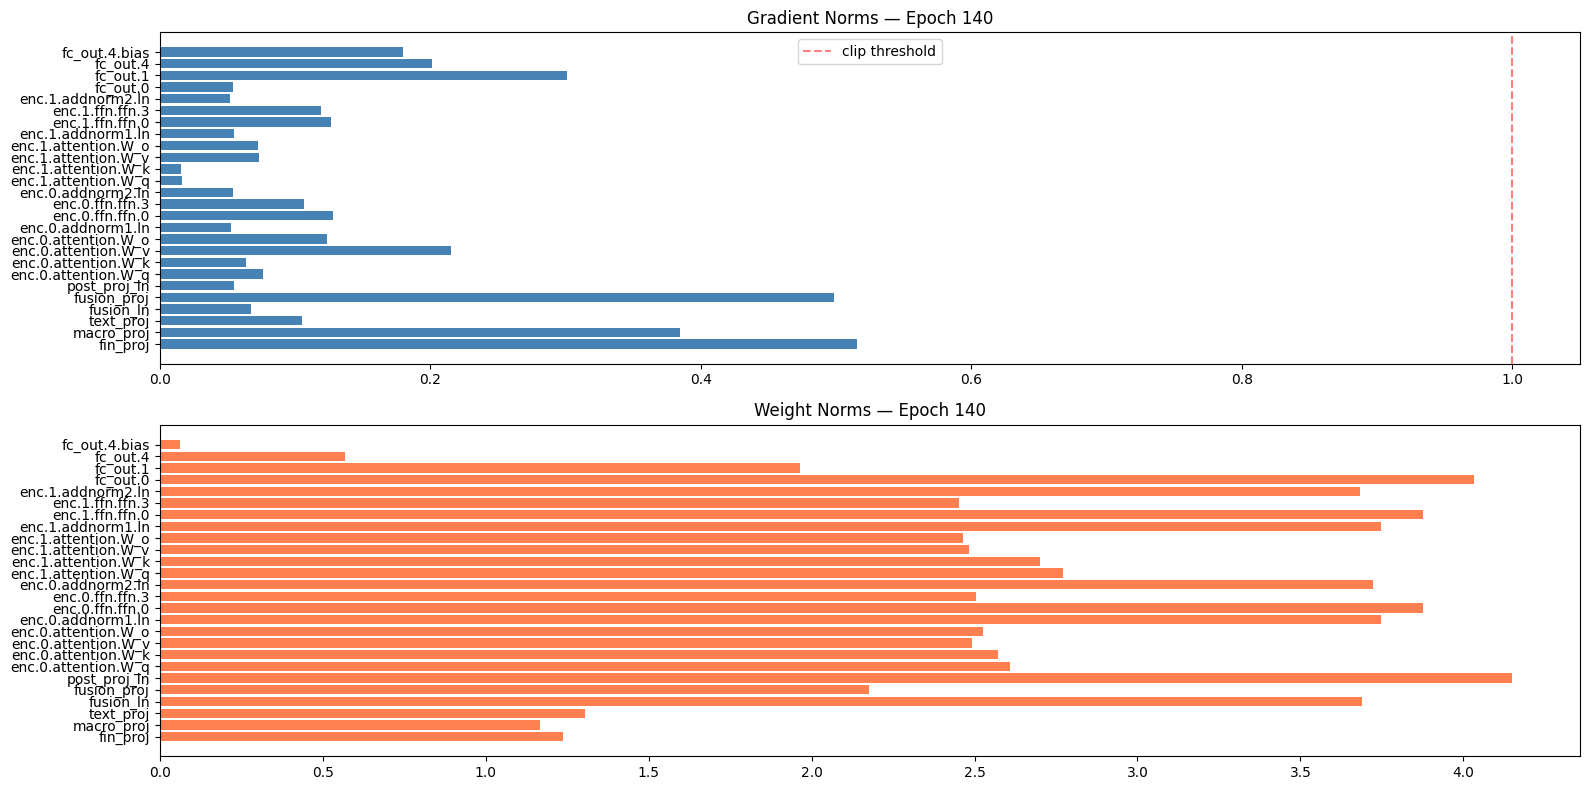

Accuratezza Direzionale Totale: 56.57%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [140/250] Loss: T:0.90548 V:1.42536 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 55.50%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [141/250] Loss: T:0.89927 V:1.43009 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 55.76%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [142/250] Loss: T:0.89456 V:1.43334 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 56.30%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [143/250] Loss: T:0.89850 V:1.42951 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 56.03%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [144/250] Loss: T:0.89809 V:1.42737 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 56.30%
Accuratezza nei 

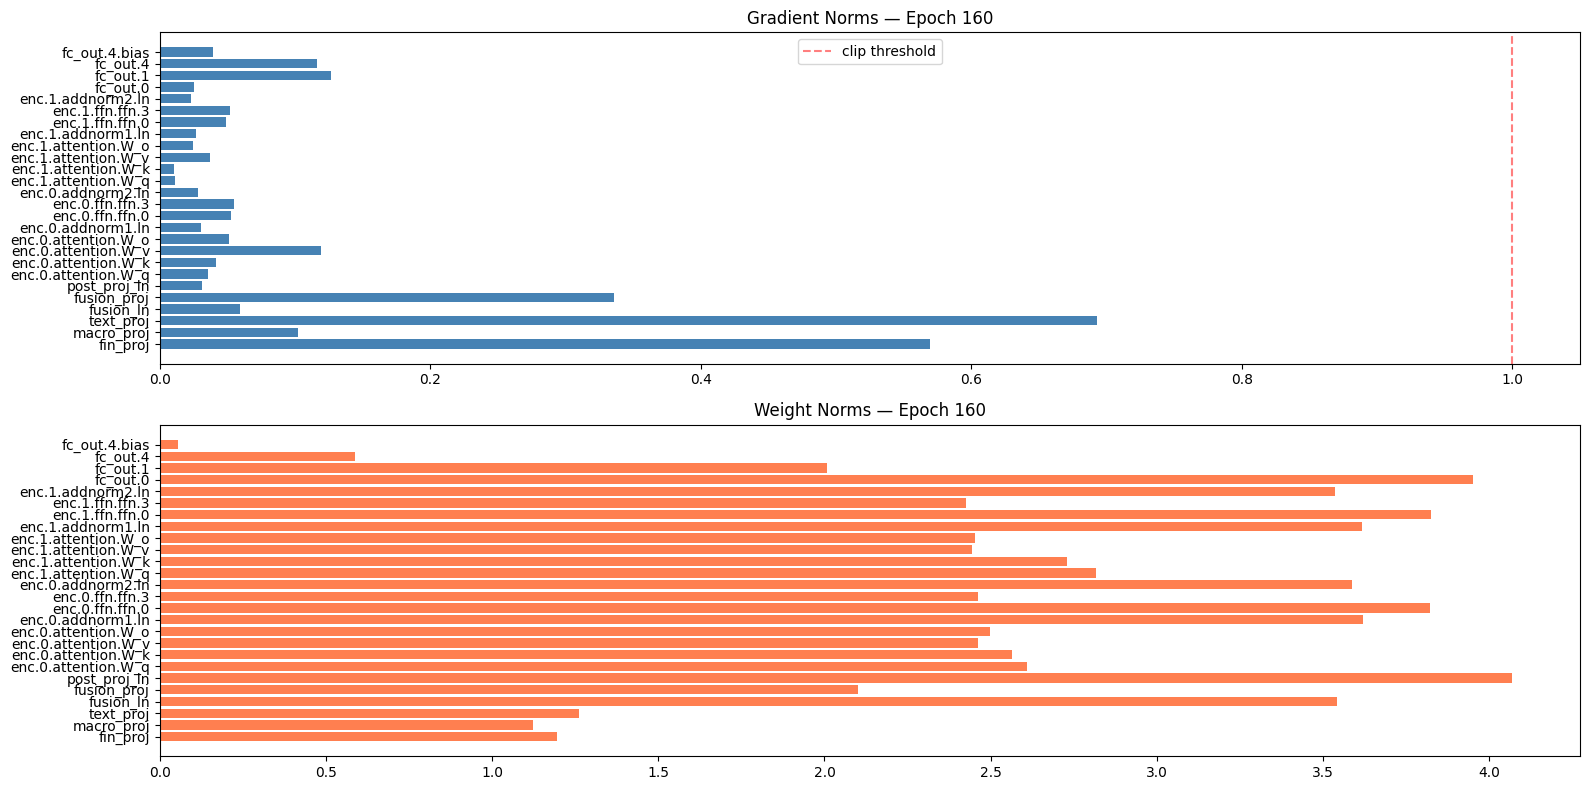

Accuratezza Direzionale Totale: 55.23%
Accuratezza nei Grandi Movimenti (Outliers): 57.89%
Epoch [160/250] Loss: T:0.88233 V:1.43709 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 52.55%
Accuratezza nei Grandi Movimenti (Outliers): 57.89%
Epoch [161/250] Loss: T:0.90248 V:1.43739 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.62%
Accuratezza nei Grandi Movimenti (Outliers): 57.89%
Epoch [162/250] Loss: T:0.89423 V:1.43483 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.89%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [163/250] Loss: T:0.88315 V:1.43088 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.16%
Accuratezza nei Grandi Movimenti (Outliers): 57.89%
Epoch [164/250] Loss: T:0.87736 V:1.44369 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.69%
Accuratezza nei 

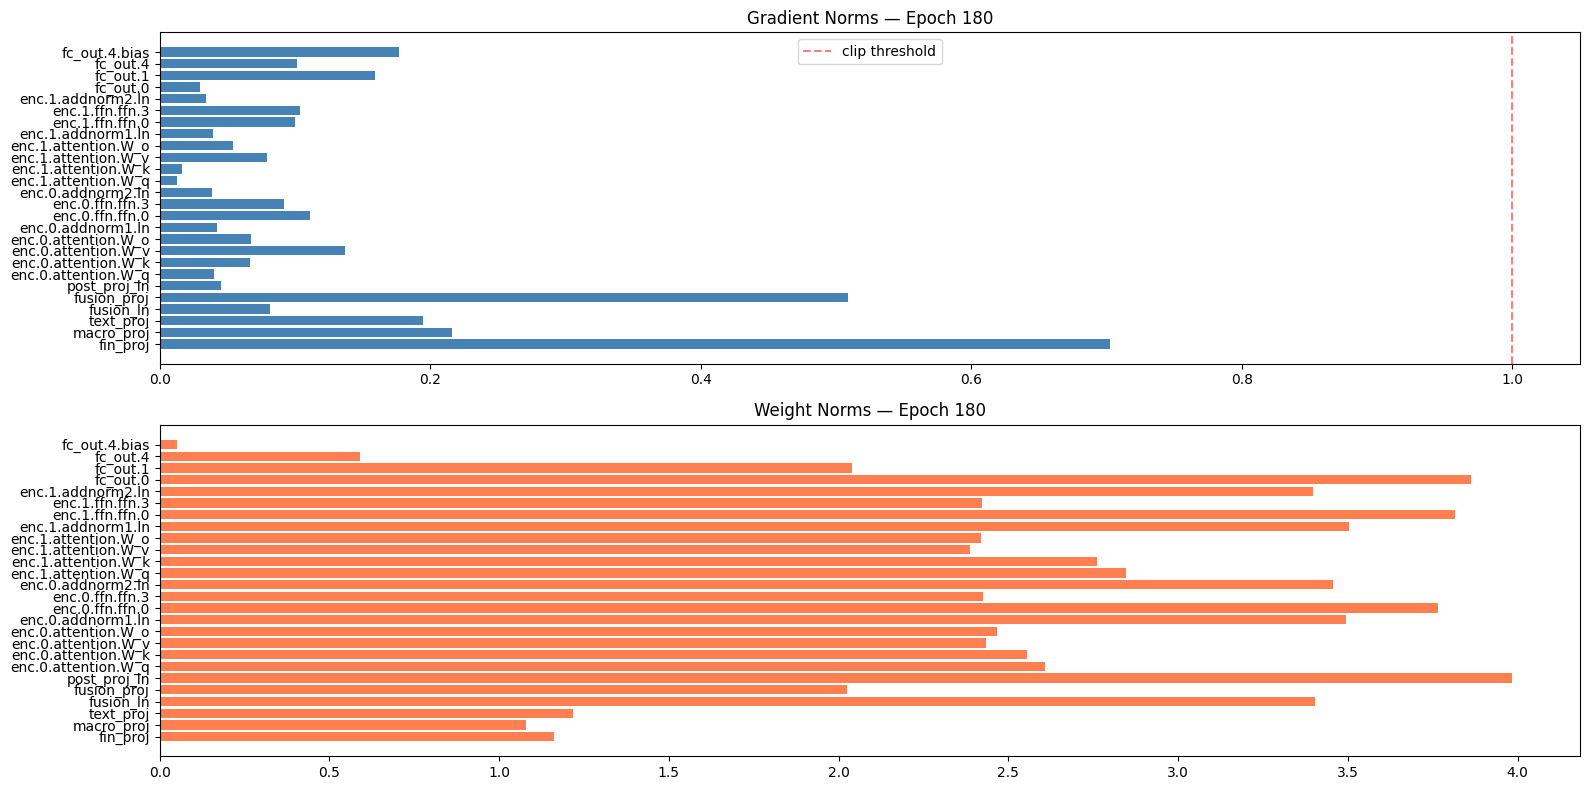

Accuratezza Direzionale Totale: 53.89%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [180/250] Loss: T:0.88798 V:1.43263 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 52.82%
Accuratezza nei Grandi Movimenti (Outliers): 57.89%
Epoch [181/250] Loss: T:0.88832 V:1.44896 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.16%
Accuratezza nei Grandi Movimenti (Outliers): 57.89%
Epoch [182/250] Loss: T:0.87948 V:1.44186 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.89%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [183/250] Loss: T:0.88027 V:1.45759 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.62%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [184/250] Loss: T:0.88642 V:1.44791 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.08%
Accuratezza nei 

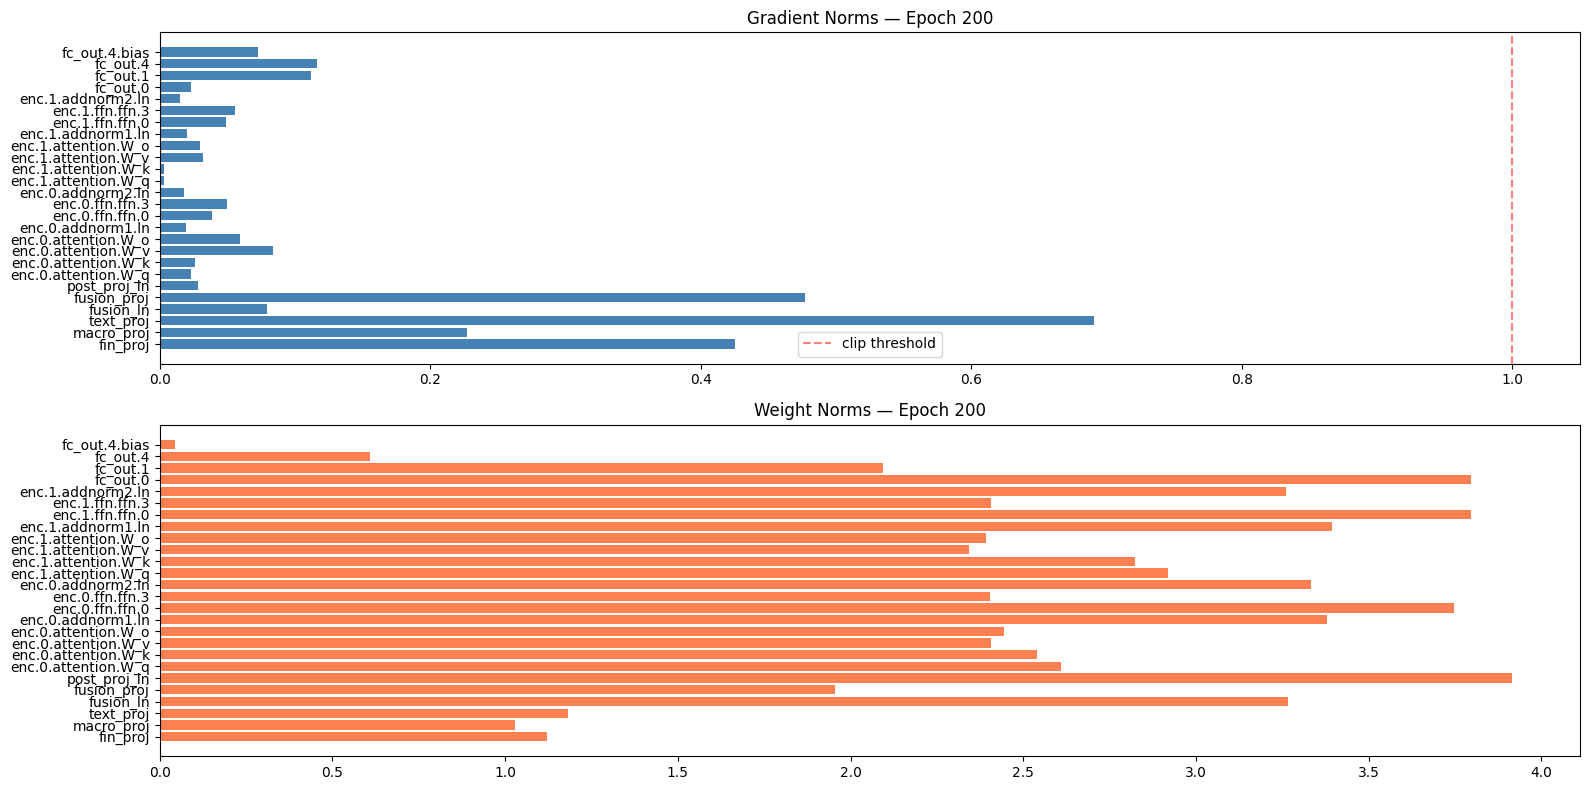

Accuratezza Direzionale Totale: 54.16%
Accuratezza nei Grandi Movimenti (Outliers): 57.89%
Epoch [200/250] Loss: T:0.87217 V:1.45269 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 52.82%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [201/250] Loss: T:0.86402 V:1.46157 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.62%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [202/250] Loss: T:0.87765 V:1.46344 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.89%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [203/250] Loss: T:0.86482 V:1.47093 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.62%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [204/250] Loss: T:0.87778 V:1.45987 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.16%
Accuratezza nei 

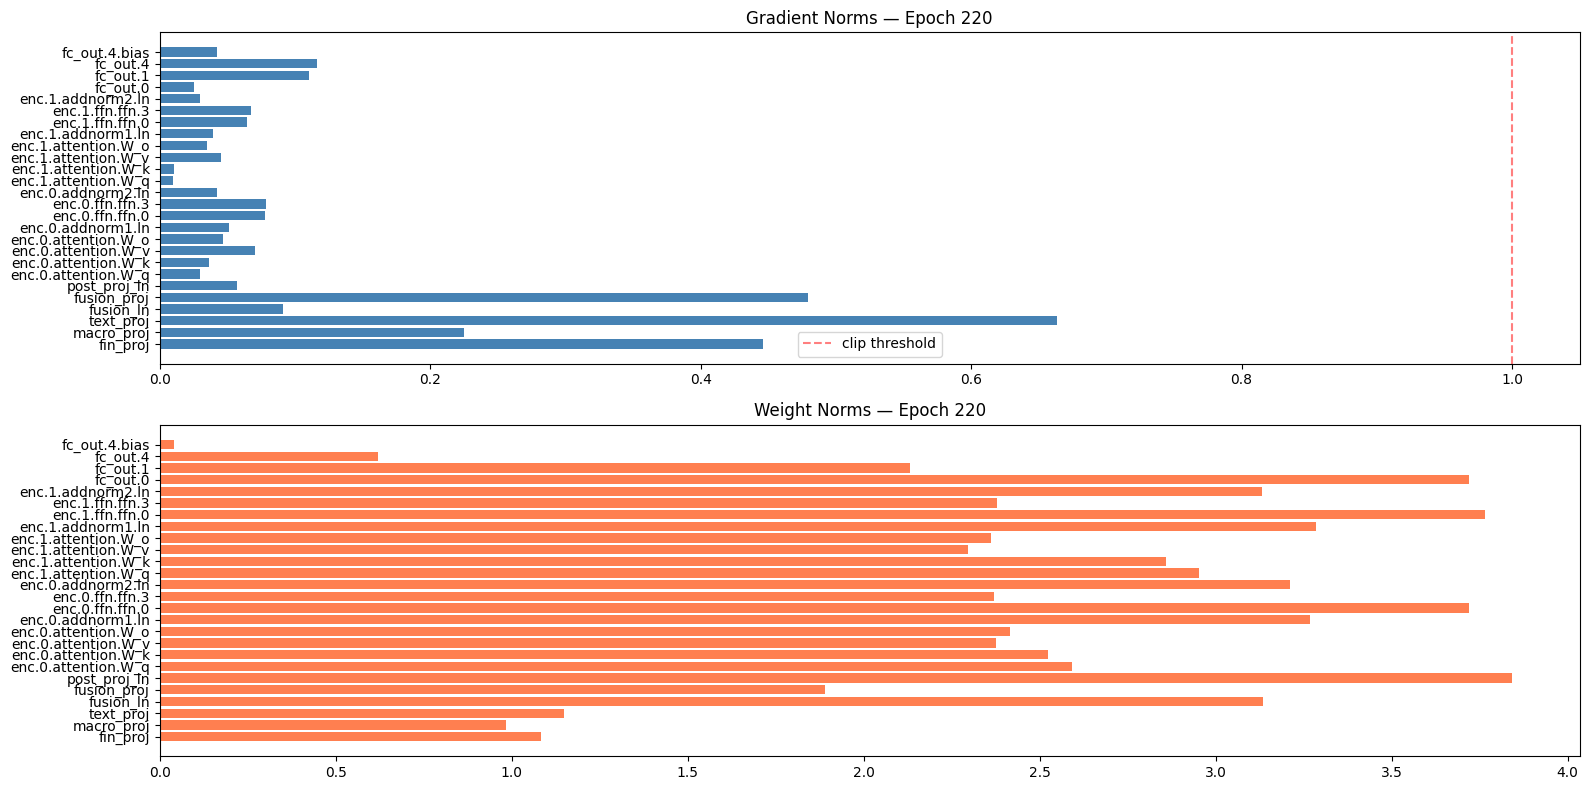

Accuratezza Direzionale Totale: 53.89%
Accuratezza nei Grandi Movimenti (Outliers): 57.89%
Epoch [220/250] Loss: T:0.86669 V:1.47839 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.35%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [221/250] Loss: T:0.86822 V:1.46561 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.89%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [222/250] Loss: T:0.87407 V:1.45521 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.42%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [223/250] Loss: T:0.87859 V:1.46292 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.89%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [224/250] Loss: T:0.87659 V:1.46380 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.08%
Accuratezza nei 

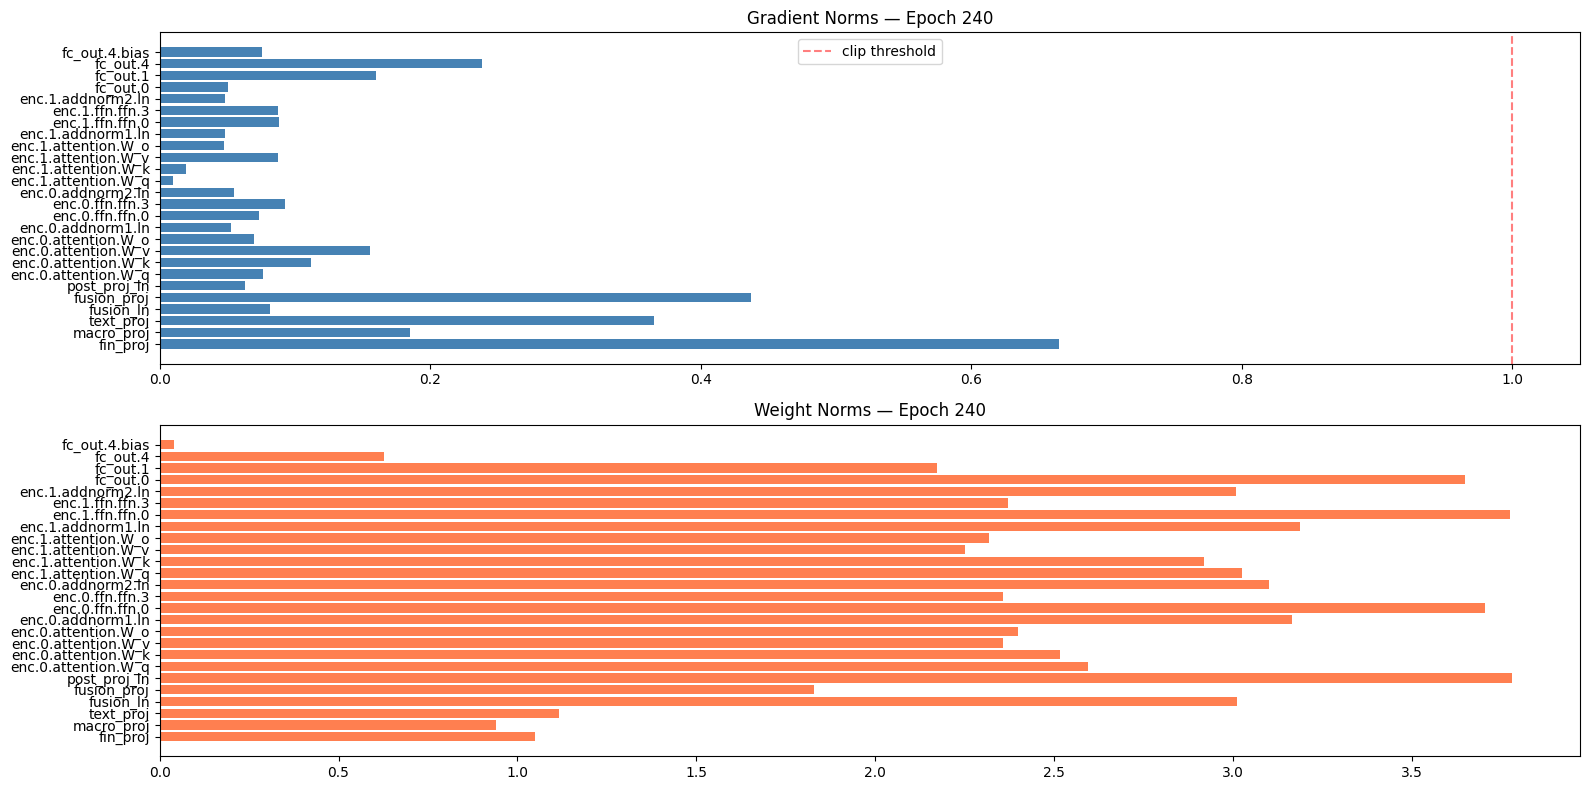

Accuratezza Direzionale Totale: 54.96%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [240/250] Loss: T:0.85430 V:1.47762 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.96%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [241/250] Loss: T:0.85335 V:1.48282 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 53.89%
Accuratezza nei Grandi Movimenti (Outliers): 63.16%
Epoch [242/250] Loss: T:0.86466 V:1.49414 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.96%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [243/250] Loss: T:0.86692 V:1.46555 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.96%
Accuratezza nei Grandi Movimenti (Outliers): 68.42%
Epoch [244/250] Loss: T:0.85814 V:1.46971 | Best: ep.136 (1.41599) | Dir Acc: None | LR: 0.000100
Accuratezza Direzionale Totale: 54.96%
Accuratezza nei 

TimeSeriesTransformer(
  (fin_proj): Linear(in_features=28, out_features=8, bias=False)
  (macro_proj): Linear(in_features=11, out_features=8, bias=False)
  (text_proj): Linear(in_features=30, out_features=8, bias=False)
  (fusion_ln): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
  (fusion_proj): Linear(in_features=24, out_features=24, bias=False)
  (post_proj_ln): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (encoder_blocks): ModuleList(
    (0-1): 2 x TransformerEncoderBlock(
      (attention): MultiHeadAttention(
        (attention): DotProductAttention(
          (dropout): Dropout(p=0.3, inplace=False)
        )
        (W_q): Linear(in_features=24, out_features=24, bias=False)
        (W_k): Linear(in_features=24, out_features=24, bias=False)
        (W_v): Linear(in_features=24, out_features=24, bias=False)
        (W_o): Linear(in_features=24, out_features=24, bias=False)
  

In [805]:
import matplotlib.pyplot as plt
epochs=250
best_val_loss = float("inf")
best_epoch = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for fin, macro, text, y in train_loader:
        fin, macro, text, y = fin.to(device), macro.to(device), text.to(device), y.to(device)
        optimizer.zero_grad()
        outputs,_ = model(fin, macro, text=text)
        loss = loss_fn(outputs, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

    #To monitor
    if (epoch + 1) % 20 == 0:
        names, grad_norms, weight_norms = [], [], []
        for name, param in model.named_parameters():
            if param.grad is not None:
                names.append(name.replace('encoder_blocks.', 'enc.').replace('.weight',''))
                grad_norms.append(param.grad.norm().item())
                weight_norms.append(param.data.norm().item())

        fig, axes = plt.subplots(2, 1, figsize=(16, 8))
        axes[0].barh(names, grad_norms, color='steelblue')
        axes[0].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='clip threshold')
        axes[0].set_title(f'Gradient Norms â€” Epoch {epoch+1}')
        axes[0].legend()
        axes[1].barh(names, weight_norms, color='coral')
        axes[1].set_title(f'Weight Norms â€” Epoch {epoch+1}')
        plt.tight_layout()
        plt.show()

    model.eval()
    val_loss = 0.0
    all_preds, all_trues = [], []

    with torch.no_grad():
        for fin, macro, text, y in test_loader:
            fin, macro, text, y = fin.to(device), macro.to(device), text.to(device), y.to(device)
            outputs,_ = model(fin, macro, text=text)
            val_loss += loss_fn(outputs, y).item()
            all_preds.append(outputs.cpu())
            all_trues.append(y.cpu())

    all_preds = torch.cat(all_preds)
    all_trues = torch.cat(all_trues)
    p_inv = target_scaler.inverse_transform(all_preds.numpy().reshape(-1,1)).flatten()
    t_inv = target_scaler.inverse_transform(all_trues.numpy().reshape(-1,1)).flatten()

    val_loss_avg = val_loss / len(test_loader)

    if val_loss_avg < best_val_loss:
       best_val_loss = val_loss_avg
       best_epoch = epoch + 1
       torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pt")

    print(
        f"Epoch [{epoch+1:03d}/{epochs}] "
        f"Loss: T:{train_loss/len(train_loader):.5f} V:{val_loss_avg:.5f} "
        f"| Best: ep.{best_epoch} ({best_val_loss:.5f}) "
        f"| Dir Acc: {directional_accuracy(t_inv, p_inv)} "
        f"| LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

print(f"{best_epoch} with val_loss {best_val_loss:.5f}")

model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pt", map_location=device))
model.eval()

## Attention of the worst return after the training

In [814]:
best_y     = float('inf')
best_batch = None
best_idx   = None

for fin, macro, text, y in train_loader:
    min_val = y.min().item()
    if min_val < best_y:
        best_y     = min_val
        best_idx   = y.argmin().item()
        best_batch = (fin, macro, text, y)

fin_b, macro_b, text_b, y_b = best_batch
print(f"y: {best_y:.4f} @ sample {best_idx} on his batch")


fin_b    = fin_b.to(device)
macro_b  = macro_b.to(device)
text_b   = text_b.to(device)
model.eval()
with torch.no_grad():
    _ = model(fin_b, macro_b, text_b)

y: -6.7061 @ sample 7 on his batch


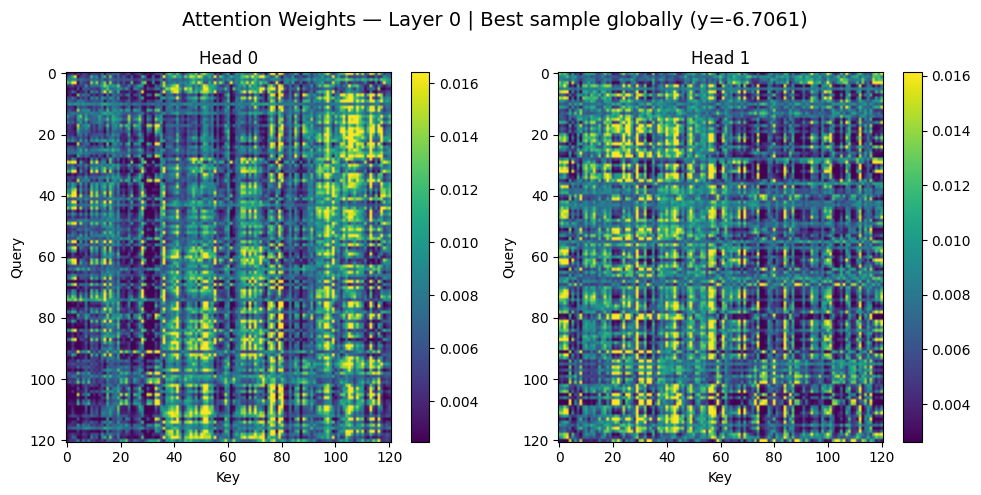

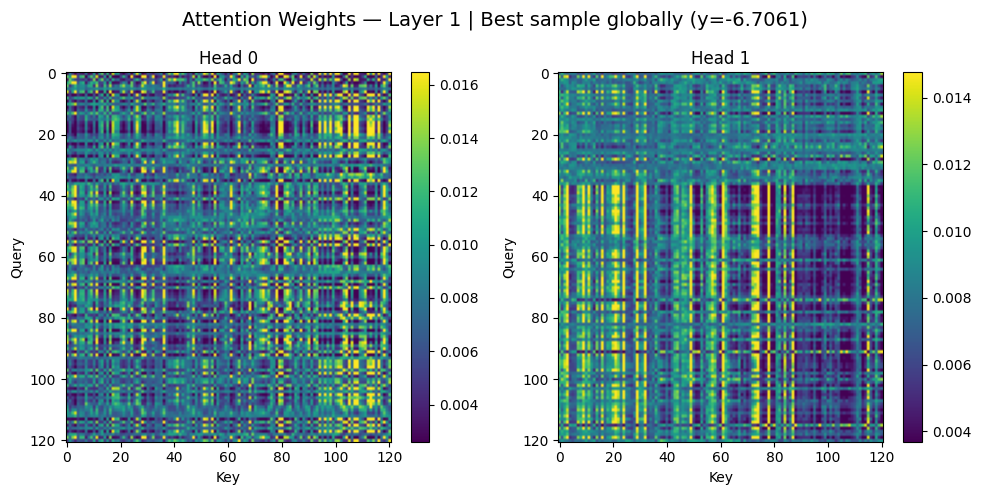

In [815]:
attn_layer0 = model.attentionWeights[0]
num_samples = len(y_b)
num_heads_model   = 2

attn_layer0 = attn_layer0.view(num_samples, num_heads_model, 121, 121)
attn_best   = attn_layer0[best_idx]

fig, axes = plt.subplots(1, num_heads_model, figsize=(5 * num_heads_model, 5))

for head_idx in range(num_heads_model):
    ax = axes[head_idx]
    head_attn = attn_best[head_idx].detach().cpu().numpy()
    vmin = np.percentile(head_attn, 5)
    vmax = np.percentile(head_attn, 95)

    im = ax.imshow(head_attn, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Head {head_idx}', fontsize=12)
    ax.set_xlabel('Key')
    ax.set_ylabel('Query')
    plt.colorbar(im, ax=ax)

fig.suptitle(f'Attention Weights â€” Layer 0 | Best sample globally (y={best_y:.4f})', fontsize=14)
plt.tight_layout()
plt.savefig('attention_heatmap_best.png', bbox_inches='tight')
plt.show()


attn_layer1 = model.attentionWeights[1]
num_samples = len(y_b)

attn_layer1 = attn_layer1.view(num_samples, num_heads_model, 121, 121)
attn_best   = attn_layer1[best_idx]

fig, axes = plt.subplots(1, num_heads_model, figsize=(5 * num_heads_model, 5))

for head_idx in range(num_heads_model):
    ax = axes[head_idx]
    head_attn = attn_best[head_idx].detach().cpu().numpy()
    vmin = np.percentile(head_attn, 5)
    vmax = np.percentile(head_attn, 95)

    im = ax.imshow(head_attn, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Head {head_idx}', fontsize=12)
    ax.set_xlabel('Key')
    ax.set_ylabel('Query')
    plt.colorbar(im, ax=ax)

fig.suptitle(f'Attention Weights â€” Layer 1 | Best sample globally (y={best_y:.4f})', fontsize=14)
plt.tight_layout()
plt.show()

## Evaluation

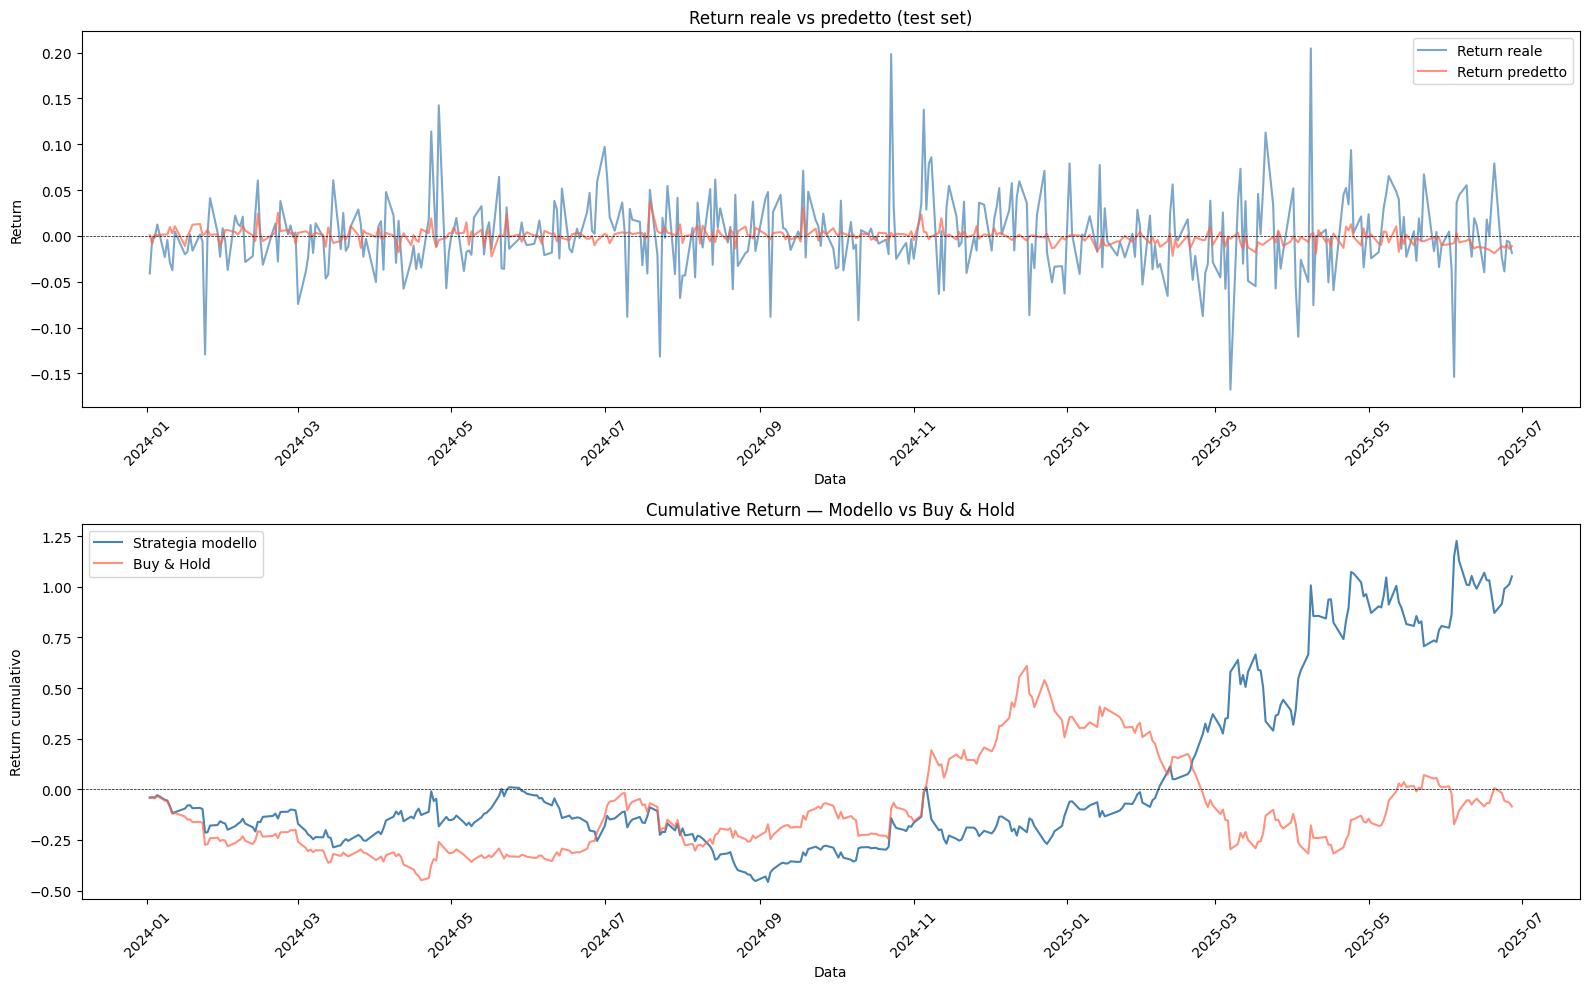

Sharpe Ratio strategia: 1.0619695850467907
Sharpe Ratio buy&hold:  0.24833111464977264


In [811]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for fin, macro, text, y in test_loader:
        fin, macro, text, y = fin.to(device), macro.to(device), text.to(device), y.to(device)
        outputs, _ = model(fin, macro, text=text)
        all_preds.append(outputs.cpu().numpy())
        all_trues.append(y.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_trues = np.concatenate(all_trues)

all_preds_inv = target_scaler.inverse_transform(all_preds.reshape(-1,1)).flatten()
all_trues_inv = target_scaler.inverse_transform(all_trues.reshape(-1,1)).flatten()

all_dates = pd.to_datetime(test_df["Date"].values[-len(all_preds_inv):])

mse = mean_squared_error(all_trues_inv, all_preds_inv)
mae = mean_absolute_error(all_trues_inv, all_preds_inv)

positions = np.where(all_preds_inv > 0, 1, -1)
strategy_returns    = positions * all_trues_inv
cumulative_strategy = np.cumprod(1 + strategy_returns) - 1
cumulative_buyhold  = np.cumprod(1 + all_trues_inv) - 1

fig, axes = plt.subplots(2, 1, figsize=(16, 10))


axes[0].plot(all_dates, all_trues_inv, label="Return reale",    alpha=0.7, color="steelblue")
axes[0].plot(all_dates, all_preds_inv, label="Return predetto", alpha=0.7, color="tomato")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_title("Return reale vs predetto (test set)")
axes[0].set_xlabel("Data")
axes[0].set_ylabel("Return")
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)


axes[1].plot(all_dates, cumulative_strategy, label="Strategia modello", color="steelblue")
axes[1].plot(all_dates, cumulative_buyhold,  label="Buy & Hold",        color="tomato", alpha=0.7)
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_title("Cumulative Return â€” Modello vs Buy & Hold")
axes[1].set_xlabel("Data")
axes[1].set_ylabel("Return cumulativo")
axes[1].legend()
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

trading_days = 256
sharpe_strategy = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(trading_days)
sharpe_buyhold  = (all_trues_inv.mean()    / all_trues_inv.std())    * np.sqrt(trading_days)

print(f"Sharpe Ratio strategia: {sharpe_strategy}")
print(f"Sharpe Ratio buy&hold:  {sharpe_buyhold}")


In [812]:
weights = model.fin_proj.weight.detach().cpu().numpy()
importances = np.abs(weights).mean(axis=0)
pd.Series(importances, index=FIN_FEATURES_ALL).sort_values(ascending=False)

,0
Volume_ZScore,0.117109
Fut_PC5,0.097945
Ticker,0.088622
EMA_50,0.085413
Excess_vs_SP500,0.084158
Return_5,0.076431
Vol_Ratio,0.075859
Fut_PC3,0.075387
RSI,0.075047
EMA_20,0.071153


# Conclusion

Overall, the model doesn't work.

I've tried different approaches, but still the main issue remains the fact the It tend to predict zero. As daily return are noise and tend to be around zero.
With Relu I've obtained the worst results, while with the others, things seemed to be better.

I think that first some improvement need to be done in the regression head, sometime I had better result without using an activation function. Also, using only the last step, didn't seem right. Maybe a better approach could be considering only those rows with the highest attention score. So the predicted return could have been somehow a weighted combination of past financial returns that occured in similar past period.

Also, another aspect I had doubt about was considering all the features as value. I've tried using only the financial ones, but didn't change much. Maybe It is more reasonable to use the features that explains the returns as values, such as fama french factor models. But some of the features are actually the one used, just diffrently manipulated. Still, It also reasonable to simply use all as done in this project.


Second, the only thing in which the model was quite constant were its ability to predict large returns. Either If It was a big or small model.


This made me think that the original purpose for which were created the model was wrong. Return are too noisy, better predict an anomaly event, for which the model seemed to be very good.

I've tried to change the purpose of the model from regression to classification. The main issue was that considering only big changes of the prices reduce drastically the dimension of the dataset. While using the classification on the sign give the same result as predict only zero.


Overall ,some action could have be done on the loss function, in order to change the minimization objective, but I didn't know which one to choose.


Finally, the main issue which will be there despite any changes, is the overfitting problem. As soon as I increase its dimension, the training tends to overfit, while very small models, e.g (1 layer, 1 head, 2 projection*3), seemed to have a decreasing loss.


Despite that, there were good sign of a model able to work, as for some training It seemed to focus on the prediction of high changes.

Another problem was that for the same set of training parameters sometimes the model tend to be very good or very bad, it seemed instable and random. Thatâ€™s why at the end Iâ€™ve decided to not to use Optuna. To be honest, Iâ€™ve done several trial with It, but when I tried the best result didnâ€™t work well, I guess for the same reason just explained.

In order to fix this, one possible approach could have been to use not only one ticker, but the returns of different tickers and their dynamics, as all the functions were created to work with any stock, one idea could have been to use different stocks and their lables and then train the model in order to allow It to understand how the market works, and maybe then fine tune It to a specific stock or maybe task.

Another improvement could have been done to the target. With this model Iâ€™ve tried to change the target with volatility prediction.
The one for which it seemed to work good, was the prediction of the next five days volatility. Not only for the correlation with the true volatility change, but because the attention seemed to work better, as in the heatmap shown above, seemed to focus on specific days, and each layer seemed to focus on different horizons.


In conclusion, I think that the architecture need much more work, but using different stock might allow the model to be more stable.